GROUP NUMBER: 3

GROUP MEMBER: A.HEMANT KUMAAR, JACK LICHWA , PRITHIKA K


# **PIT STOP ANALYSIS PROJECT**

## **PROJECT BACKGROUND**

Formula 1 (F1) is the pinnacle of motorsport, combining elite driver skill with cutting-edge engineering. A critical and often race-deciding element of F1 strategy is the **pit stop**  a brief pause in which a team changes tires, makes aerodynamic adjustments, or responds to race incidents. The duration of a pit stop, even down to fractions of a second, can determine whether a driver retains or loses a podium position.

For top-finishing drivers (those who finish in the top 3), pit stop strategy is especially high-stakes. A slow stop can cost a driver a podium; an efficiently timed stop can vault them ahead of a competitor. Understanding what factors influence the **maximum pit stop duration** experienced by top 3 finishers has implications for race engineering, team strategy optimization, and performance analytics.

This study investigates whether historical race data, tire information, and race conditions can be used to predict the maximum pit stop duration among the top three drivers in a Formula 1 race. Can the maximum pit stop duration for the top 3 drivers in a Formula 1 race be predicted using race context and historical performance data?

## **DATASET**

**Source**: All datasets come from Kaggle: “Formula 1 Race Data” by jtrotman. https://www.kaggle.com/datasets/jtrotman/formula-1-race-data?resource=download&select=lap_times.csv

They contain historical Formula 1 data from 1950 onwards, including race results, circuits, drivers, constructors, lap times, pit stops, qualifying, sprint results, and season standings.

**Key Variable**:
At this stage, we are exploring all variables from the pit stops, races, circuits, drivers, constructors, lap times, qualifying, and results datasets. Final selection of key predictor variables will be based on further analysis and exploratory data analysis (EDA), including correlations, distributions, and relevance to pit stop duration.

**Data Type**: The datasets include a mix of numeric, categorical, ordinal, and datetime variables:

- Numeric: milliseconds, lap, round, year, alt, points, positionOrder
- Categorical: driverId, surname, constructorId, constructor name, circuitId, location, country, status
- Ordinal: stop (pit stop sequence), grid position, and finishing positions
- Datetime: race dates (races.date) and driver birth dates (drivers.dob)

These variables provide the foundation for preprocessing and exploratory analysis to identify potential predictors for pit stop duration.



| File | Description |
|---|---|
| `pit_stops.csv` | Per-stop timing data for every driver in every race (1994+) |
| `results.csv` | Final race outcomes: grid, finish position, points, laps, fastest lap |
| `races.csv` | Race metadata: year, round, circuit, date |
| `circuits.csv` | Circuit details: name, location, country, altitude |
| `drivers.csv` | Driver info: name, nationality, date of birth |
| `constructors.csv` | Constructor (team) name and nationality |
| `lap_times.csv` | Per-lap timing for every driver (used to derive race pace features) |
| `qualifying.csv` | Q1/Q2/Q3 qualifying times per driver per race |
| `driver_standings.csv` | Cumulative championship standings after each race |
| `constructor_standings.csv` | Cumulative constructor championship standings |
| `status.csv` | Lookup: race exit status (Finished, Engine, Accident, etc.) |


### **SETUP AND DATA LOADING**

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (11, 5)

print('Libraries loaded.')

Libraries loaded.


In [104]:
import kagglehub

# Download latest version using kagglehub
path = kagglehub.dataset_download("jtrotman/formula-1-race-data")

DATA_PATH = path + '/' # Set DATA_PATH to the downloaded directory

pit_stops            = pd.read_csv(DATA_PATH + 'pit_stops.csv')
results              = pd.read_csv(DATA_PATH + 'results.csv')
races                = pd.read_csv(DATA_PATH + 'races.csv')
circuits             = pd.read_csv(DATA_PATH + 'circuits.csv')
drivers              = pd.read_csv(DATA_PATH + 'drivers.csv')
constructors         = pd.read_csv(DATA_PATH + 'constructors.csv')
lap_times            = pd.read_csv(DATA_PATH + 'lap_times.csv')
qualifying           = pd.read_csv(DATA_PATH + 'qualifying.csv')
driver_standings     = pd.read_csv(DATA_PATH + 'driver_standings.csv')
constructor_standings= pd.read_csv(DATA_PATH + 'constructor_standings.csv')
status               = pd.read_csv(DATA_PATH + 'status.csv')

print('All files loaded.')

all_dfs = {
    'pit_stops': pit_stops, 'results': results, 'races': races,
    'circuits': circuits, 'drivers': drivers, 'constructors': constructors,
    'lap_times': lap_times, 'qualifying': qualifying,
    'driver_standings': driver_standings, 'status': status
}
print(f"\n{'File':<28} {'Rows':>10} {'Cols':>6}")
print('-' * 46)
for name, df in all_dfs.items():
    print(f'{name:<28} {df.shape[0]:>10,} {df.shape[1]:>6}')

All files loaded.

File                               Rows   Cols
----------------------------------------------
pit_stops                        22,193      7
results                          27,304     18
races                             1,171     18
circuits                             78      9
drivers                             865      9
constructors                        214      5
lap_times                       618,766      6
qualifying                       11,036      9
driver_standings                 35,427      7
status                              140      2


**Key Variable Definitions & Data Types**

The dataset contains a mix of numeric, categorical, ordinal, and datetime variables across files.

`pit_stops.csv` — Primary File
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `raceId` | Integer — **Nominal** | Join key | Links to `races.csv` |
| `driverId` | Integer — **Nominal** | Join key | Links to `drivers.csv` |
| `stop` | Integer — **Ordinal** | Predictor | Pit stop sequence number (1st, 2nd, 3rd…) |
| `lap` | Integer — **Discrete** | Predictor | Lap on which the pit stop occurred |
| `time` | String (HH:MM:SS) | Context | Clock time of pit stop |
| `duration` | Float — **Continuous** | Feature / Target-component | Pit stop duration in seconds |
| `milliseconds` | Integer — **Continuous** | Feature / Target-component | Duration in milliseconds |

 `results.csv` — Race Outcomes
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `grid` | Integer — **Ordinal** | Predictor | Starting grid position |
| `positionOrder` | Integer — **Ordinal** | Filter / Predictor | Final finishing position |
| `points` | Float — **Continuous** | Predictor | Championship points earned |
| `laps` | Integer — **Discrete** | Predictor | Total laps completed |
| `fastestLapSpeed` | Float — **Continuous** | Predictor | Speed (km/h) of driver's fastest lap |
| `statusId` | Integer — **Nominal** | Filter | Links to `status.csv` |
| `constructorId` | Integer — **Nominal** | Join key | Links to `constructors.csv` |

`races.csv`
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `year` | Integer — **Ordinal** | Predictor | Season year |
| `round` | Integer — **Ordinal** | Predictor | Race round within the season |
| `circuitId` | Integer — **Nominal** | Join key | Links to `circuits.csv` |
| `date` | String → **Datetime** | Feature | Date of the race |

`circuits.csv`
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `name` | String — **Categorical** | Predictor | Circuit name |
| `country` | String — **Categorical** | Predictor | Host country |
| `location` | String — **Categorical** | Context | City/region |
| `alt` | Integer — **Continuous** | Predictor | Circuit altitude (meters) — affects engine/tire behavior |
| `lat` / `lng` | Float — **Continuous** | Context | Geographic coordinates |

`drivers.csv`
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `surname` | String — **Categorical** | Context | Driver last name |
| `nationality` | String — **Categorical** | Predictor | Driver nationality |
| `dob` | String → **Datetime** | Feature-eng | Date of birth (used to compute driver age at race) |

`qualifying.csv`
| Variable | Data Type | Role | Description |
|---|---|---|---|
| `position` | Integer — **Ordinal** | Predictor | Final qualifying position |
| `q1`, `q2`, `q3` | String → Float — **Continuous** | Predictor | Qualifying lap times per session |


### DATA PROFILING AND CLEANING

This section prepares the dataset for analysis by checking data quality and applying the basic cleaning needed for the project.

In [105]:
# --- Inspecting data ---
print('=== DATA Analysis ===')

print('\npit_stops info:\n')
pit_stops.info()

print('\n\nresults info (selected columns):\n')
results_subset = results[['grid', 'positionOrder', 'points', 'laps']]
results_subset.info()

print('\n\nraces info (selected columns):\n')
races_subset = races[['date', 'year']]
races_subset.info()

print('\n\ncircuits info (selected columns):\n')
circuits_subset = circuits[['circuitId', 'name', 'country', 'alt', 'lng', 'lat', 'url']]
circuits_subset.info()

print('\n\ndrivers info (selected columns):\n')
drivers_subset = drivers[['driverId', 'surname', 'dob']]
drivers_subset.info()

print("\n\nqualyfing inf (selected columns):\n")
qualifying_subset = qualifying[
    ['raceId', 'driverId', 'constructorId', 'position', 'q1', 'q2', 'q3']
]
qualifying_subset.info()


=== DATA Analysis ===

pit_stops info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22193 entries, 0 to 22192
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   raceId        22193 non-null  int64 
 1   driverId      22193 non-null  int64 
 2   stop          22193 non-null  int64 
 3   lap           22193 non-null  int64 
 4   time          22193 non-null  object
 5   duration      22193 non-null  object
 6   milliseconds  22193 non-null  object
dtypes: int64(4), object(3)
memory usage: 1.2+ MB


results info (selected columns):

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27304 entries, 0 to 27303
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   grid           27304 non-null  object 
 1   positionOrder  27304 non-null  int64  
 2   points         27304 non-null  float64
 3   laps           27304 non-null  int64  
dtypes: float64(

In [106]:
# === Core type conversions and cleaning ===

# duration, milliseconds numeric; keep time as string for now (HH:MM:SS)
pit_stops['duration'] = pd.to_numeric(pit_stops['duration'], errors='coerce')
pit_stops['milliseconds'] = pd.to_numeric(pit_stops['milliseconds'], errors='coerce')

# Drop pit_stop rows without usable duration
pit_stops = pit_stops.dropna(subset=['duration']).copy()

# results
results['grid'] = pd.to_numeric(results['grid'], errors='coerce').astype('Int64')

# races
races['date'] = pd.to_datetime(races['date'], errors='coerce')

# drivers
drivers['dob'] = pd.to_datetime(drivers['dob'], errors='coerce')

# qualyfing
def lap_to_seconds(x):
    if pd.isna(x) or x == r'\N':
        return np.nan
    x = str(x).strip()
    if ':' in x:
        m, s = x.split(':')
        return int(m) * 60 + float(s)
    return float(x)

for col in ['q1', 'q2', 'q3']:
    if col in qualifying.columns:
        qualifying[col] = qualifying[col].apply(lap_to_seconds)

print("\nConverted dtypes (selected):")
print("pit_stops:", pit_stops[['duration', 'milliseconds']].dtypes.to_dict())
print("results:", {c: results[c].dtype for c in ['grid', 'positionOrder', 'points', 'laps'] if c in results.columns})
print("races:", races[['year', 'round', 'date']].dtypes.to_dict())
print("circuits:", circuits[['alt', 'lat', 'lng']].dtypes.to_dict())
print("drivers:", drivers[['dob']].dtypes.to_dict())
print("qualifying:", {c: qualifying[c].dtype for c in ['position', 'q1', 'q2', 'q3'] if c in qualifying.columns})


Converted dtypes (selected):
pit_stops: {'duration': dtype('float64'), 'milliseconds': dtype('float64')}
results: {'grid': Int64Dtype(), 'positionOrder': dtype('int64'), 'points': dtype('float64'), 'laps': dtype('int64')}
races: {'year': dtype('int64'), 'round': dtype('int64'), 'date': dtype('<M8[ns]')}
circuits: {'alt': dtype('int64'), 'lat': dtype('float64'), 'lng': dtype('float64')}
drivers: {'dob': dtype('<M8[ns]')}
qualifying: {'position': dtype('int64'), 'q1': dtype('float64'), 'q2': dtype('float64'), 'q3': dtype('float64')}


### MERGE DATASETS

In [107]:
# Build one unified source dataset (driver-race grain, expanded with pit stop detail)
race_dim = races[['raceId', 'year', 'round', 'circuitId', 'name', 'date']].rename(columns={'name': 'race_name'})
circuit_dim = circuits[['circuitId', 'name', 'country', 'alt', 'lat', 'lng']].rename(columns={'name': 'circuit_name'})
driver_dim = drivers[['driverId', 'forename', 'surname', 'nationality', 'dob']]
constructor_dim = constructors[['constructorId', 'name']].rename(columns={'name': 'constructor_name'})
qualifying_dim = qualifying[['raceId', 'driverId', 'position', 'q1']]

results_base = results[['raceId', 'driverId', 'constructorId', 'grid', 'laps', 'positionOrder', 'points', 'statusId']].copy()
results_base['laps'] = pd.to_numeric(results_base['laps'], errors='coerce').astype('Int64')
results_base['positionOrder'] = pd.to_numeric(results_base['positionOrder'], errors='coerce').astype('Int64')

# Pit stop aggregates per driver per race
pit_driver = (
    pit_stops.groupby(['raceId', 'driverId'], as_index=False)
    .agg(
        total_pit_stops=('stop', 'count'),
        avg_stop_lap=('lap', 'mean'),
        mean_pit_duration=('duration', 'mean'),
        max_pit_duration=('duration', 'max'),
        min_pit_duration=('duration', 'min')
    )
)

# Pit stop detail per stop (lap-level) — needed for place-specific pivot in feature construction
pit_detail = pit_stops[['raceId', 'driverId', 'stop', 'lap', 'duration', 'milliseconds']].copy()
pit_detail['lap'] = pd.to_numeric(pit_detail['lap'], errors='coerce')
pit_detail['stop'] = pd.to_numeric(pit_detail['stop'], errors='coerce')

driver_race_df = (
    results_base
    .merge(race_dim,        on='raceId',               how='left')
    .merge(circuit_dim,     on='circuitId',             how='left')
    .merge(driver_dim,      on='driverId',              how='left')
    .merge(constructor_dim, on='constructorId',         how='left')
    .merge(qualifying_dim,  on=['raceId', 'driverId'],  how='left')
    .merge(pit_driver,      on=['raceId', 'driverId'],  how='left')
)

driver_race_df['position'] = driver_race_df['position'].astype('Int64')
driver_race_df['total_pit_stops'] = driver_race_df['total_pit_stops'].astype('Int64')

# Expand to pit-stop grain (one row per driver-race-stop)
driver_race_df = driver_race_df.merge(pit_detail, on=["raceId", "driverId"], how="left")

print('Unified dataset complete.')
print(f'driver_race_df shape (driver-race grain): {driver_race_df.shape}')
driver_race_df.info()


Unified dataset complete.
driver_race_df shape (driver-race grain): (37545, 34)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37545 entries, 0 to 37544
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   raceId             37545 non-null  int64         
 1   driverId           37545 non-null  int64         
 2   constructorId      37545 non-null  int64         
 3   grid               37503 non-null  Int64         
 4   laps               37545 non-null  Int64         
 5   positionOrder      37545 non-null  Int64         
 6   points             37545 non-null  float64       
 7   statusId           37545 non-null  int64         
 8   year               37545 non-null  int64         
 9   round              37545 non-null  int64         
 10  circuitId          37545 non-null  int64         
 11  race_name          37545 non-null  object        
 12  date               37545 non-null  d

Based on above there is missing pit stop data for races.

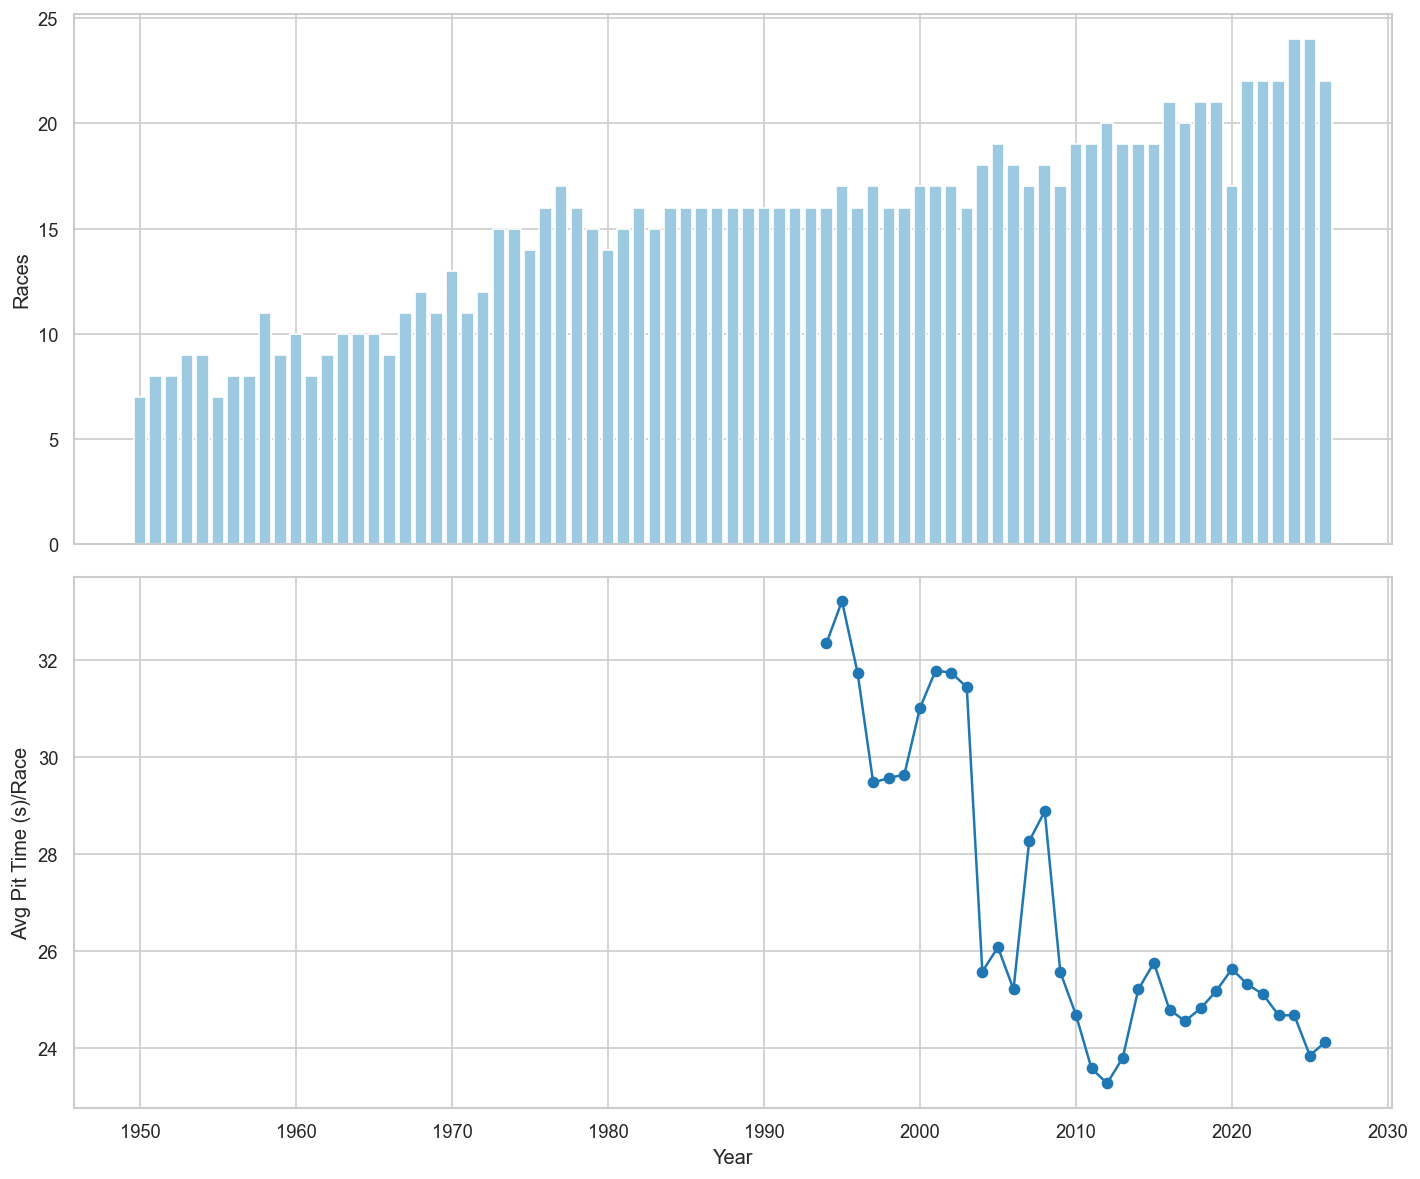

In [108]:
pit_per_race = (
    driver_race_df.groupby(['year', 'raceId'])['total_pit_stops']
    .sum(min_count=1)
    .reset_index(name='pitstops_per_race')

)

pit_time_per_race = (
    pit_stops.merge(races[['raceId', 'year']], on='raceId', how='left')
    .groupby(['year', 'raceId'])['duration']
    .agg(avg_pit_time='mean', total_pit_time='sum')
    .reset_index()
)

plot_df = pd.DataFrame({
    'races': races.groupby('year')['raceId'].nunique(),
    'avg_pitstops_per_race': pit_per_race.groupby('year')['pitstops_per_race'].mean(),
    'avg_pit_time_per_race': pit_time_per_race.groupby('year')['avg_pit_time'].mean(),
    'total_pit_time_per_race': pit_time_per_race.groupby('year')['total_pit_time'].mean()
}).sort_index()

fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
ax[0].bar(plot_df.index, plot_df['races'], color='#9ecae1')
ax[0].set_ylabel('Races')

ax[1].plot(plot_df.index, plot_df['avg_pit_time_per_race'], marker='o', color='#1f77b4')
ax[1].set_ylabel('Avg Pit Time (s)/Race')

ax[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

In [109]:
# Remove rows from before 1994
driver_race_df = driver_race_df[driver_race_df['year'] >= 1994].copy()
driver_race_df.to_csv('driver_race_tmp.csv', index=False)


Remaing missing data will be handled in the EDA section.

## EDA

This section will explore, analyze and visualize pit stop dataset. It will enhance dataset with engineered features.

### DATA PREPROCESSING AND FEATURE ENGINEERING

In [110]:
# Start EDA from Dataset-section handoff (fallback to driver_level_df for compatibility)
df = pd.read_csv('driver_race_tmp.csv')


display(df.head(5))
print('\nShape:')
print(df.shape)
print('\nData types :')
print(df.dtypes)

,raceId,driverId,constructorId,grid,laps,positionOrder,points,statusId,year,round,...,q1,total_pit_stops,avg_stop_lap,mean_pit_duration,max_pit_duration,min_pit_duration,stop,lap,duration,milliseconds
0,18,1,1,1.0,58,1,10.0,1,2008,1,...,86.572,2.0,30.5,24.5255,24.797,24.254,1.0,18.0,24.797,24797.0
1,18,1,1,1.0,58,1,10.0,1,2008,1,...,86.572,2.0,30.5,24.5255,24.797,24.254,2.0,43.0,24.254,24254.0
2,18,2,2,5.0,58,2,8.0,1,2008,1,...,85.960,2.0,32.5,22.6355,22.900,22.371,1.0,21.0,22.900,22900.0
3,18,2,2,5.0,58,2,8.0,1,2008,1,...,85.960,2.0,32.5,22.6355,22.900,22.371,2.0,44.0,22.371,22371.0
4,18,3,3,7.0,58,3,6.0,1,2008,1,...,86.295,2.0,32.0,23.5095,24.146,22.873,1.0,21.0,24.146,24146.0



Shape:
(23144, 34)

Data types :
raceId                 int64
driverId               int64
constructorId          int64
grid                 float64
laps                   int64
positionOrder          int64
points               float64
statusId               int64
year                   int64
round                  int64
circuitId              int64
race_name             object
date                  object
circuit_name          object
country               object
alt                    int64
lat                  float64
lng                  float64
forename              object
surname               object
nationality           object
dob                   object
constructor_name      object
position             float64
q1                   float64
total_pit_stops      float64
avg_stop_lap         float64
mean_pit_duration    float64
max_pit_duration     float64
min_pit_duration     float64
stop                 float64
lap                  float64
duration             float64
milliseco

In [111]:
print('=== eda_df missing values (top 20 columns with data gaps) ===')
missing_counts = df.isna().sum().sort_values(ascending=False)
display(missing_counts.head(20).to_frame('missing_count'))

display(df.describe(include=[np.number]))

=== eda_df missing values (top 20 columns with data gaps) ===


,missing_count
q1,3212
position,2914
lap,1692
total_pit_stops,1692
avg_stop_lap,1692
mean_pit_duration,1692
stop,1692
milliseconds,1692
max_pit_duration,1692
min_pit_duration,1692


,raceId,driverId,constructorId,grid,laps,positionOrder,points,statusId,year,round,...,q1,total_pit_stops,avg_stop_lap,mean_pit_duration,max_pit_duration,min_pit_duration,stop,lap,duration,milliseconds
count,23144.000000,23144.000000,23144.000000,23102.000000,23144.000000,23144.000000,23144.000000,23144.000000,23144.000000,23144.000000,...,19932.000000,21452.000000,21452.000000,21452.000000,21452.000000,21452.000000,21452.000000,21452.000000,21452.000000,21452.000000
mean,593.386277,318.876599,45.293597,10.933382,54.541695,10.706274,3.420152,8.766851,2010.418769,9.898894,...,88.158877,2.304587,27.671033,26.368010,28.101043,24.882907,1.678445,27.671033,26.368010,26368.009743
std,433.113482,383.611385,71.047705,6.306874,17.320403,6.004669,5.843255,15.861587,9.014498,5.633997,...,15.605379,0.970206,8.980676,5.176486,6.592850,5.066070,0.845038,14.529261,5.832912,5832.911767
min,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1994.000000,1.000000,...,53.904000,1.000000,1.000000,15.110000,16.241000,8.757000,1.000000,1.000000,8.757000,8757.000000
25%,146.000000,17.000000,5.000000,5.000000,51.000000,6.000000,0.000000,1.000000,2003.000000,5.000000,...,78.194000,2.000000,22.000000,22.651000,23.423000,21.868000,1.000000,16.000000,22.549000,22549.000000
50%,851.000000,55.000000,10.000000,11.000000,57.000000,11.000000,0.000000,4.000000,2011.000000,10.000000,...,86.792000,2.000000,27.500000,25.145500,26.420000,24.101000,1.000000,27.000000,24.943000,24943.000000
75%,992.000000,821.000000,25.000000,16.000000,67.000000,16.000000,5.000000,11.000000,2018.000000,14.000000,...,95.708250,3.000000,33.500000,29.252250,30.793000,27.760000,2.000000,39.000000,29.284000,29284.000000
max,1171.000000,866.000000,217.000000,28.000000,87.000000,28.000000,50.000000,142.000000,2026.000000,24.000000,...,1002.640000,6.000000,70.000000,59.885000,59.885000,59.885000,7.000000,78.000000,59.885000,59885.000000


**HANDLING MISSING VALUES**

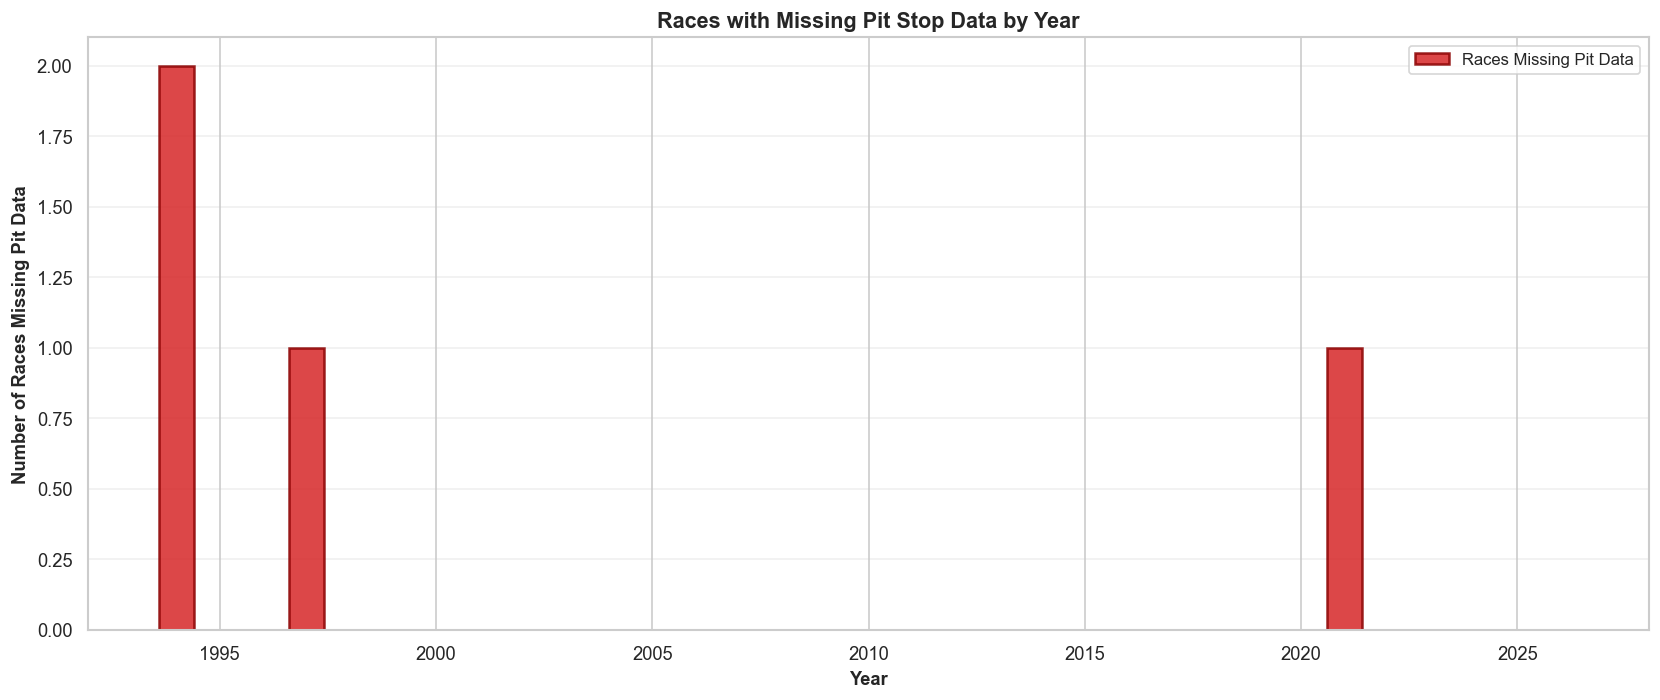

In [112]:
# --- Visualization: Races with Missing Pit Stop Data by Year (using df) ---

# Simplest logic: per (year, race), count non-null max_pit_duration; missing race => count == 0
races_missing_pit_by_year = (
    df.groupby(['year', 'raceId'])['max_pit_duration']
    .count()
    .eq(0)
    .groupby(level='year')
    .sum()
    .reset_index(name='races_missing_pit')
)

# Create bar chart
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(
    races_missing_pit_by_year['year'],
    races_missing_pit_by_year['races_missing_pit'],
    color='#d62728',
    alpha=0.85,
    edgecolor='darkred',
    linewidth=1.5,
    label='Races Missing Pit Data'
)

ax.set_xlabel('Year', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Races Missing Pit Data', fontsize=11, fontweight='bold')
ax.set_title('Races with Missing Pit Stop Data by Year', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Dropping races with missing pit stop data, as they cannot contribute to the target variable.

In [113]:
df_cleaned = df.dropna(subset=['max_pit_duration']).copy()
print(f"Cleaned df shape: {df_cleaned.shape}")

# Drop races where any of the top-3 finishers lack pit stop data
podium_coverage = (
    df_cleaned[df_cleaned['positionOrder'].between(1, 3)]
    .drop_duplicates(subset=['raceId', 'driverId'])
    .groupby('raceId')['positionOrder']
    .nunique()
)
complete_races = podium_coverage[podium_coverage == 3].index
incomplete = len(podium_coverage) - len(complete_races)
df_cleaned = df_cleaned[df_cleaned['raceId'].isin(complete_races)].copy()
print(f"Dropped {incomplete} races with incomplete podium pit data. Remaining shape: {df_cleaned.shape}")

Cleaned df shape: (21452, 34)
Dropped 6 races with incomplete podium pit data. Remaining shape: (21256, 34)


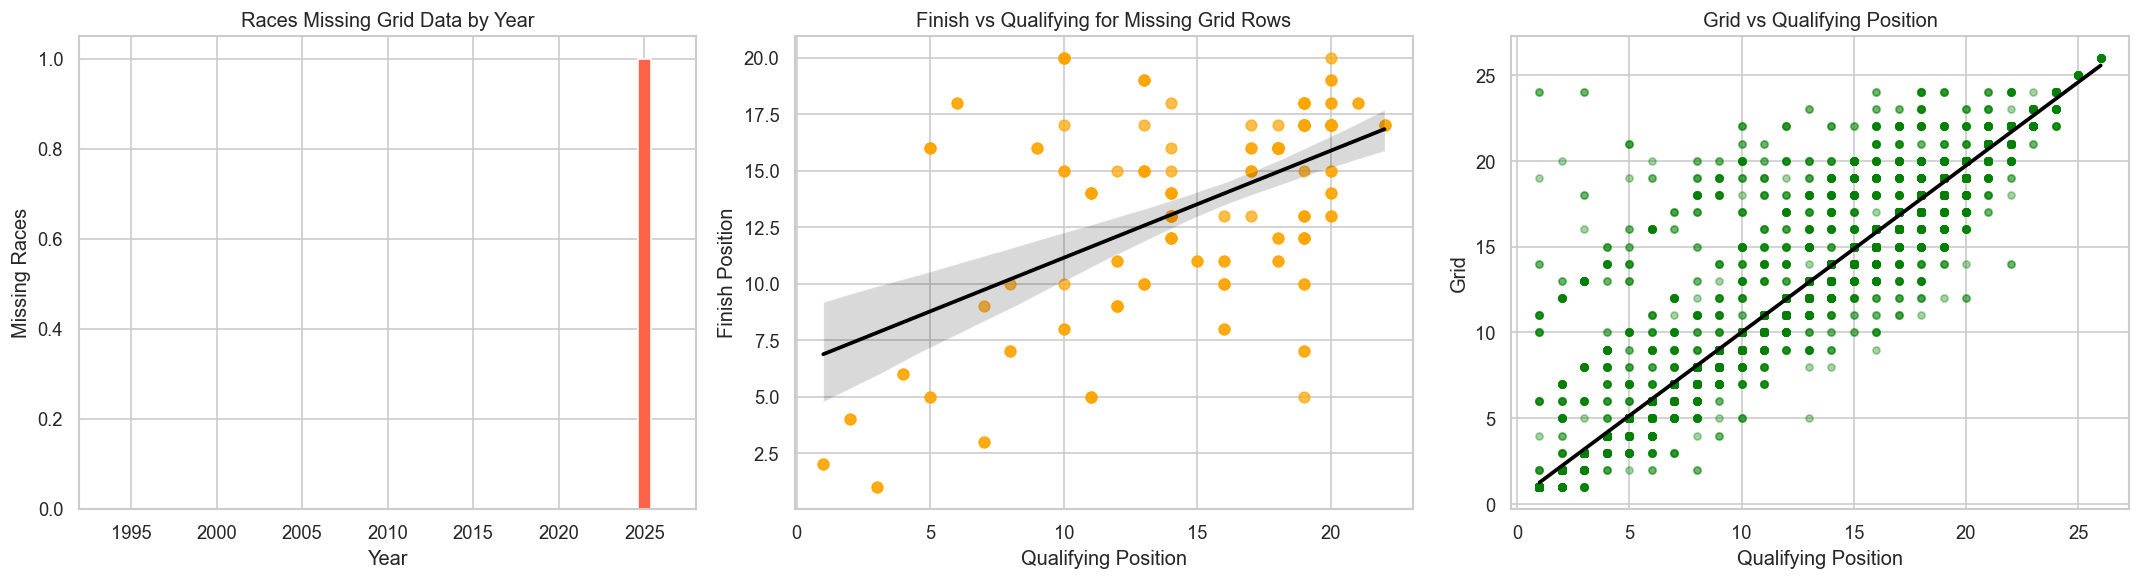

Missing grid diagnostics summary:
Missing grid race count: 1
Missing grid row count: 163

Year-level missing grid counts (non-zero only):
 year  missing_grid_races
 2025                   1


In [114]:

# treat grid 0 as missing
df_cleaned['grid'] = df_cleaned['grid'].replace(0, np.nan)

race_grid_missing = (
    df_cleaned.groupby(['year', 'raceId'])['grid']
    .apply(lambda s: s.notna().any())
    .reset_index(name='has_grid_data')
)
race_grid_missing['missing_grid_race'] = ~race_grid_missing['has_grid_data']

year_grid_missing = (
    race_grid_missing.groupby('year', as_index=False)['missing_grid_race']
    .sum()
    .rename(columns={'missing_grid_race': 'missing_grid_races'})
)

missing_grid_race_count = int(race_grid_missing['missing_grid_race'].sum())
missing_grid_row_count = int(df_cleaned['grid'].isna().sum())

missing_grid_detail = df_cleaned.loc[
    df_cleaned['grid'].isna(),
    ['position', 'positionOrder']
].dropna()

analysis_df = df_cleaned[['position', 'grid']].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(year_grid_missing['year'], year_grid_missing['missing_grid_races'], color='tomato')
axes[0].set_title('Races Missing Grid Data by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Missing Races')

sns.regplot(
    data=missing_grid_detail,
    x='position',
    y='positionOrder',
    scatter_kws={'color': 'orange', 's': 40, 'alpha': 0.7},
    line_kws={'color': 'black'},
    ax=axes[1]
)
axes[1].set_title('Finish vs Qualifying for Missing Grid Rows')
axes[1].set_xlabel('Qualifying Position')
axes[1].set_ylabel('Finish Position')

sns.regplot(
    data=analysis_df,
    x='position',
    y='grid',
    scatter_kws={'color': 'green', 's': 18, 'alpha': 0.35},
    line_kws={'color': 'black'},
    ax=axes[2]
)
axes[2].set_title('Grid vs Qualifying Position')
axes[2].set_xlabel('Qualifying Position')
axes[2].set_ylabel('Grid')

plt.tight_layout()
plt.show()

print('Missing grid diagnostics summary:')
print(f'Missing grid race count: {missing_grid_race_count}')
print(f'Missing grid row count: {missing_grid_row_count}')
print('\nYear-level missing grid counts (non-zero only):')
print(year_grid_missing[year_grid_missing['missing_grid_races'] > 0].to_string(index=False))

Dataset is missing grid (starting position) just for one race. Since qualifying position and grid position are strongly corelated, we will impute grid variable with qualifying position.

In [115]:
df_cleaned.loc[df_cleaned['grid'].isna(), 'grid'] = df_cleaned['position']

# Identify rows where grid is still NaN
rows_missing_grid = df_cleaned['grid'].isna()
print("Rows with grid still missing after imputation:", rows_missing_grid.sum())

print(df_cleaned.loc[rows_missing_grid])
df_cleaned = df_cleaned[~rows_missing_grid].copy()

print("Remaining columns with missing values:")
print(df_cleaned.isna().sum().sort_values(ascending=False).head(5))

print("\nDataset head:")
df_cleaned.head(5)

Rows with grid still missing after imputation: 1
       raceId  driverId  constructorId  grid  laps  positionOrder  points  \
17903    1012       848              5   NaN    55             10     1.0   

       statusId  year  round  ...  q1 total_pit_stops avg_stop_lap  \
17903        11  2019      3  ... NaN             1.0         19.0   

      mean_pit_duration max_pit_duration  min_pit_duration  stop   lap  \
17903            23.215           23.215            23.215   1.0  19.0   

      duration milliseconds  
17903   23.215      23215.0  

[1 rows x 34 columns]
Remaining columns with missing values:
q1               2711
position         2445
driverId            0
raceId              0
constructorId       0
dtype: int64

Dataset head:


,raceId,driverId,constructorId,grid,laps,positionOrder,points,statusId,year,round,...,q1,total_pit_stops,avg_stop_lap,mean_pit_duration,max_pit_duration,min_pit_duration,stop,lap,duration,milliseconds
0,18,1,1,1.0,58,1,10.0,1,2008,1,...,86.572,2.0,30.5,24.5255,24.797,24.254,1.0,18.0,24.797,24797.0
1,18,1,1,1.0,58,1,10.0,1,2008,1,...,86.572,2.0,30.5,24.5255,24.797,24.254,2.0,43.0,24.254,24254.0
2,18,2,2,5.0,58,2,8.0,1,2008,1,...,85.960,2.0,32.5,22.6355,22.900,22.371,1.0,21.0,22.900,22900.0
3,18,2,2,5.0,58,2,8.0,1,2008,1,...,85.960,2.0,32.5,22.6355,22.900,22.371,2.0,44.0,22.371,22371.0
4,18,3,3,7.0,58,3,6.0,1,2008,1,...,86.295,2.0,32.0,23.5095,24.146,22.873,1.0,21.0,24.146,24146.0


Handle qualyfying race metrics

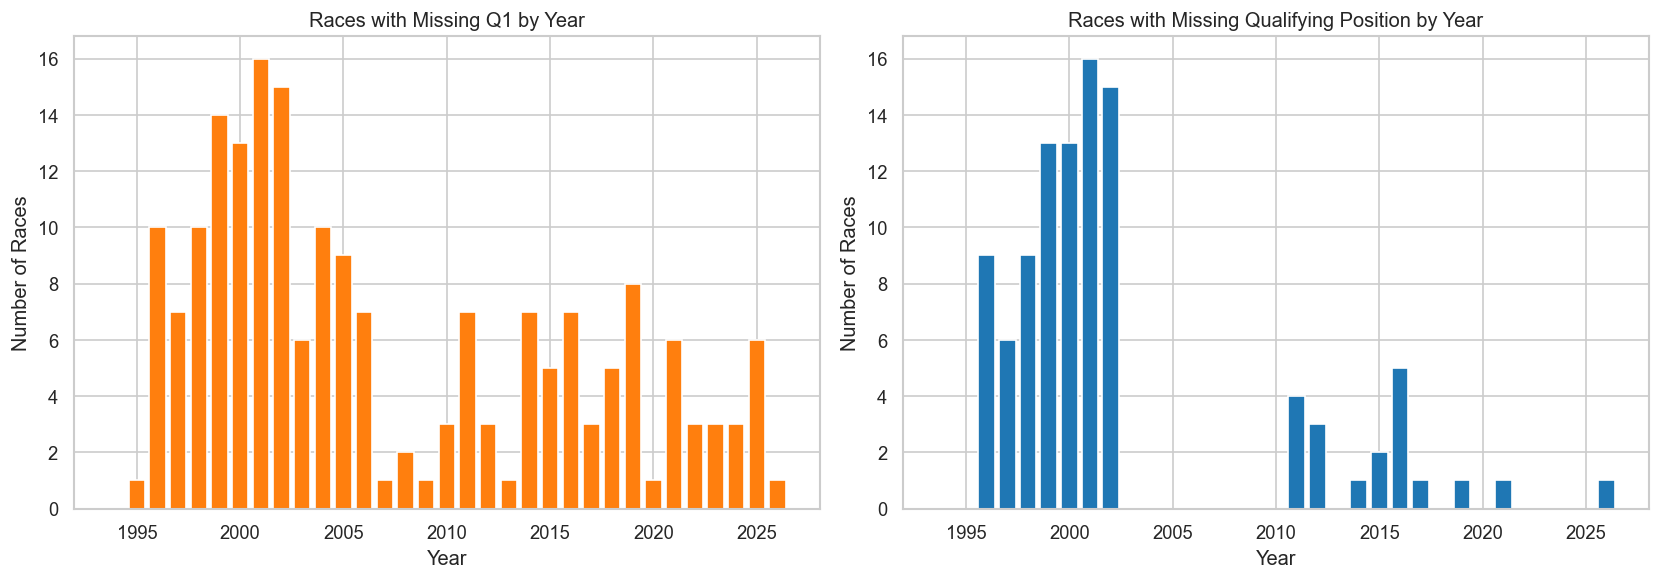

In [116]:

# --- Missing Q1 & Qualifying Position by race ---

quali_missing = (
    df_cleaned
    .groupby(['year', 'raceId', 'race_name'], as_index=False)
    .agg(
        any_q1_missing=('q1', lambda s: s.isna().any()),
        any_quali_pos_missing=('position', lambda s: s.isna().any()),
        q1_missing_count=('q1', lambda s: s.isna().sum()),
        quali_pos_missing_count=('position', lambda s: s.isna().sum()),
        total_drivers=('driverId', 'nunique')
    )
)

# Year-level counts
year_quali_missing = (
    quali_missing
    .groupby('year', as_index=False)
    .agg(
        races_missing_q1=('any_q1_missing', 'sum'),
        races_missing_quali_pos=('any_quali_pos_missing', 'sum'),
        total_races=('raceId', 'nunique')
    )
)

year_quali_missing['rate_missing_q1'] = (
    year_quali_missing['races_missing_q1'] / year_quali_missing['total_races']
)
year_quali_missing['rate_missing_quali_pos'] = (
    year_quali_missing['races_missing_quali_pos'] / year_quali_missing['total_races']
)

# Plots: races with missing Q1 / qualifying_position by year
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(year_quali_missing['year'], year_quali_missing['races_missing_q1'],
            color='tab:orange')
axes[0].set_title('Races with Missing Q1 by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Races')

axes[1].bar(year_quali_missing['year'],
            year_quali_missing['races_missing_quali_pos'],
            color='tab:blue')
axes[1].set_title('Races with Missing Qualifying Position by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Races')

plt.tight_layout()
plt.show()



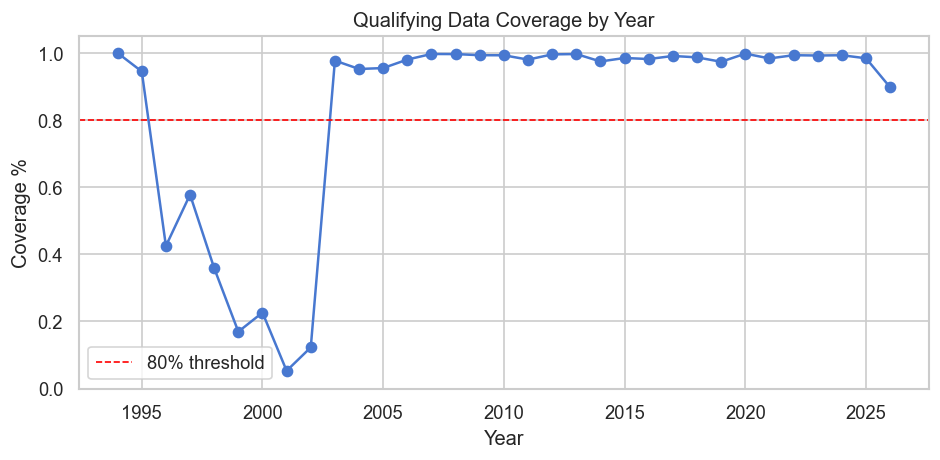

In [117]:
qf_data_coverage = df_cleaned.groupby('year').apply(
    lambda g: (g['q1'].notna() & g['position'].notna()).mean()
).rename('coverage').reset_index()

#  80% threshold for data coverage
plt.figure(figsize=(8, 4))
plt.plot(qf_data_coverage['year'], qf_data_coverage['coverage'], marker='o')
plt.axhline(0.8, color='red', linestyle='--', linewidth=1, label='80% threshold')
plt.ylim(0, 1.05)
plt.xlabel('Year')
plt.ylabel('Coverage %')
plt.title('Qualifying Data Coverage by Year')
plt.legend()
plt.tight_layout()
plt.show()


In [118]:
df_cleaned = df_cleaned[df_cleaned['year'] >= 2003].copy()

# Impute qualifying_position directly from grid where it is missing
df_cleaned.loc[df_cleaned['position'].isna(), 'position'] = df_cleaned['grid']

#median for a driver on that circuit
q1_driver_circuit = (
    df_cleaned
    .groupby(['driverId', 'circuitId'])['q1']
    .transform('median')
)

df_cleaned['q1'] = df_cleaned['q1'].fillna(q1_driver_circuit)

#median q1 by position for remaining
q1_by_quali = (
    df_cleaned
    .groupby('position')['q1']
    .transform('median')
)

df_cleaned['q1'] = df_cleaned['q1'].fillna(q1_by_quali)

df_cleaned.info()


# Flag top-3 finishers with their podium place
df_cleaned['place'] = df_cleaned['positionOrder'].map({1: 'pos1', 2: 'pos2', 3: 'pos3'})

<class 'pandas.core.frame.DataFrame'>
Index: 16899 entries, 0 to 23143
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   raceId             16899 non-null  int64  
 1   driverId           16899 non-null  int64  
 2   constructorId      16899 non-null  int64  
 3   grid               16899 non-null  float64
 4   laps               16899 non-null  int64  
 5   positionOrder      16899 non-null  int64  
 6   points             16899 non-null  float64
 7   statusId           16899 non-null  int64  
 8   year               16899 non-null  int64  
 9   round              16899 non-null  int64  
 10  circuitId          16899 non-null  int64  
 11  race_name          16899 non-null  object 
 12  date               16899 non-null  object 
 13  circuit_name       16899 non-null  object 
 14  country            16899 non-null  object 
 15  alt                16899 non-null  int64  
 16  lat                16899 no

| Where / Variable | What this means in the data | What was done in code |
|---|---|---|
| Pit-stop data | Pit-stop records are unavailable before 1994 | Removed pre-1994 races (1950-1993), since pit-stop variables are core project targets |
| Grid position | Starting grid position is unavailable for one race | 84 rows came from that race; grid was filled from qualifying position, and the final unresolved case was removed (raceId 1012, driverId 848) |
| Qualifying session times (q2, q3) | Structural gaps (drivers eliminated before later sessions) | Dropped q2 and q3 from analysis |
| Qualifying position | Qualifying rank has gaps, especially in earlier seasons | Coverage was analyzed by year and years with about 80%+ qualifying coverage were retained (year >= 2003); remaining qualifying_position gaps were then imputed from grid, resulting in 0 unavailable values in the kept subset |
| Q1 time | Q1 has broad gaps before imputation (1,538 unavailable values before the year filter step) | Applied two-stage imputation: median by (driverId, circuitId) first to preserve driver-circuit pattern, then median by qualifying position for remaining gaps; final kept subset has 0 unavailable q1 values (8,694/8,694 non-null) |




**DATA ENGINEERING & FEATURE CONSTRUCTION**

This section engineers race-level features from top-3 finishers only, using `df_cleaned` as the base and enriching it with podium-specific pit-stop behavior. Instead of relying only on averages, the workflow keeps separate columns for first, second, and third place drivers (for example, driver ID, grid, qualifying position, and pit metrics per place), while also retaining overall race aggregates such as maximum pit duration, mean duration, stop counts, and average stop lap. This structure allows direct comparison across podium positions within the same race and supports both descriptive analysis and downstream modeling in a single consolidated `modelling_df` table.

In [119]:
# --- DATA ENGINEERING & FEATURE CONSTRUCTION ---

# Convenience views — all derived from df_cleaned, no new data
driver_race_clean = df_cleaned.drop_duplicates(subset=['raceId', 'driverId'])
top3_df           = df_cleaned[df_cleaned['place'].notna()].drop_duplicates(subset=['raceId', 'driverId']).copy()
top3_pits         = df_cleaned[df_cleaned['place'].notna() & df_cleaned['duration'].notna()][['raceId', 'driverId', 'place', 'stop', 'lap', 'duration']].copy()

race_context = df_cleaned.groupby('raceId')[['year', 'circuit_name', 'country', 'alt']].first()

pit_agg_top3 = top3_df.groupby('raceId').agg(
    top3_pit_stops_max_duration_s=('max_pit_duration', 'max'),
    top3_pit_stops_avg_duration_s=('mean_pit_duration', 'mean'),
    top3_pit_stops_min_duration_s=('min_pit_duration', 'min'),
    top3_pit_stops_count=('total_pit_stops', 'sum'),
    top3_avg_laps_before_pit_stop=('avg_stop_lap', 'mean'),
)

pit_agg_race_all = (
    driver_race_clean[driver_race_clean['raceId'].isin(top3_df['raceId'])]
    .groupby('raceId').agg(
        race_pit_stops_max_duration_s=('max_pit_duration', 'max'),
        race_pit_stops_avg_duration_s=('mean_pit_duration', 'mean'),
        race_pit_stops_min_duration_s=('min_pit_duration', 'min'),
        race_pit_stops_count=('total_pit_stops', 'sum'),
        race_avg_laps_before_pit_stop=('avg_stop_lap', 'mean'),
    )
)

driver_col_rename = {
    'constructor_name': 'team',
    'grid': 'race_start_position',
    'position': 'qualifying_position',
    'q1': 'quali_lap_time_s',
    'laps': 'laps_completed',
}
driver_wide = top3_df.pivot(index='raceId', columns='place', values=list(driver_col_rename))
driver_wide.columns = [f"{place}_{driver_col_rename[col]}" for col, place in driver_wide.columns]

pit_place_wide = top3_df.pivot_table(
    index='raceId', columns='place',
    values=['total_pit_stops', 'mean_pit_duration', 'max_pit_duration', 'min_pit_duration', 'avg_stop_lap'],
    aggfunc='first'
)
pit_place_wide.columns = [
    f"{place}_pit_stops_count" if col == 'total_pit_stops'
    else f"{place}_pit_stops_avg_duration_s" if col == 'mean_pit_duration'
    else f"{place}_pit_stops_max_duration_s" if col == 'max_pit_duration'
    else f"{place}_pit_stops_min_duration_s" if col == 'min_pit_duration'
    else f"{place}_avg_laps_before_pit_stop"
    for col, place in pit_place_wide.columns
]

pit_merged_df = pd.concat(
    [race_context, pit_agg_top3, pit_agg_race_all, driver_wide, pit_place_wide],
    axis=1, join='inner'
).reset_index(drop=True)

skip_top3_avg = {'team', 'qualifying_position', 'avg_laps_before_pit_stop'}
pos1_cols_raw = sorted(c for c in pit_merged_df.columns if c.startswith('pos1_'))
top3_avg_cols = []
for metric in (c.replace('pos1_', '') for c in pos1_cols_raw):
    if metric in skip_top3_avg:
        continue
    avg_col = f"top3_avg_{metric}"
    pit_merged_df[avg_col] = pit_merged_df[[f"pos1_{metric}", f"pos2_{metric}", f"pos3_{metric}"]].mean(axis=1)
    top3_avg_cols.append(avg_col)

print(f"df_cleaned shape: {df_cleaned.shape}")
print(f"top3_df shape:    {top3_df.shape}")
print(f"pit_merged_df shape: {pit_merged_df.shape}")


df_cleaned shape: (16899, 35)
top3_df shape:    (1338, 35)
pit_merged_df shape: (446, 51)


**RENAMING AND REORDERING COLUMNS**

In [120]:
pit_merged_df_clean = pit_merged_df.rename(columns={
    "year": "race_year",
    "country": "race_country",
    "alt": "race_altitude_m",
    "circuit_name": "race_circuit",
    "position": "qualifying_position",
}).copy()

top3_aggregate_order = [
    "top3_pit_stops_max_duration_s", "top3_pit_stops_avg_duration_s", "top3_pit_stops_min_duration_s",
    "top3_pit_stops_count", "top3_avg_laps_before_pit_stop",
]

race_aggregate_order = [
    "race_pit_stops_max_duration_s", "race_pit_stops_avg_duration_s", "race_pit_stops_min_duration_s",
    "race_pit_stops_count", "race_avg_laps_before_pit_stop",
]

pos1_cols = sorted(c for c in pit_merged_df_clean.columns if c.startswith("pos1_"))
pos2_cols = sorted(c for c in pit_merged_df_clean.columns if c.startswith("pos2_"))
pos3_cols = sorted(c for c in pit_merged_df_clean.columns if c.startswith("pos3_"))


base_col_order = ["race_year", "race_circuit", "race_country", "race_altitude_m"]

ordered_cols = (
    base_col_order +
    top3_aggregate_order + top3_avg_cols +
    race_aggregate_order +
    pos1_cols + pos2_cols + pos3_cols
)
ordered_cols += [c for c in pit_merged_df_clean.columns if c not in ordered_cols]

pit_merged_df_clean = pit_merged_df_clean[ordered_cols].sort_values("race_year").reset_index(drop=True)

display(pit_merged_df_clean.head(5))
print(f"Total columns: {pit_merged_df_clean.shape[1]}")
print(list(pit_merged_df_clean.columns))


# --- DRIVER-LEVEL CLASSIFICATION DATASET ---
clf_df = (
    driver_race_clean[[
        'raceId', 'driverId', 'year', 'circuit_name', 'country', 'alt',
        'constructor_name', 'grid', 'position', 'q1', 'laps', 'points', 'positionOrder',
        'total_pit_stops', 'mean_pit_duration',
    ]]
    .rename(columns={
        'total_pit_stops': 'driver_pit_stops_count',
        'mean_pit_duration': 'driver_pit_stops_avg_duration_s',
    })
    .copy()
)

clf_df['top3_finish'] = (clf_df['positionOrder'] <= 3).astype(int)
clf_df = clf_df.rename(columns={
    'year':             'race_year',
    'circuit_name':     'race_circuit',
    'country':          'race_country',
    'alt':              'race_altitude_m',
    'constructor_name': 'team',
    'grid':             'race_start_position',
    'position':         'qualifying_position',
    'q1':               'quali_lap_time_s',
    'laps':             'laps_completed',
}).drop(columns='positionOrder')

clf_df = (clf_df
    .merge(pit_agg_race_all.reset_index(), on='raceId', how='left')
    .drop(columns=['raceId', 'driverId'])
)

clf_df = clf_df[clf_df['race_year'] >= 2011].dropna(subset=['top3_finish', 'race_start_position']).reset_index(drop=True)

clf_col_order = [
    'race_year', 'race_circuit', 'race_country', 'race_altitude_m',
    'team', 'race_start_position', 'qualifying_position', 'quali_lap_time_s', 'laps_completed', 'points',
    'driver_pit_stops_count', 'driver_pit_stops_avg_duration_s',
    'race_pit_stops_count', 'race_pit_stops_avg_duration_s',
    'race_pit_stops_max_duration_s', 'race_pit_stops_min_duration_s', 'race_avg_laps_before_pit_stop',
    'top3_finish',
]
clf_df = clf_df[[c for c in clf_col_order if c in clf_df.columns]]

print(f"Classification dataset shape: {clf_df.shape}")
print(f"Top-3 finish rate: {clf_df['top3_finish'].mean():.1%}")
display(clf_df.head())


,race_year,race_circuit,race_country,race_altitude_m,top3_pit_stops_max_duration_s,top3_pit_stops_avg_duration_s,top3_pit_stops_min_duration_s,top3_pit_stops_count,top3_avg_laps_before_pit_stop,top3_avg_laps_completed,...,pos3_avg_laps_before_pit_stop,pos3_laps_completed,pos3_pit_stops_avg_duration_s,pos3_pit_stops_count,pos3_pit_stops_max_duration_s,pos3_pit_stops_min_duration_s,pos3_quali_lap_time_s,pos3_qualifying_position,pos3_race_start_position,pos3_team
0,2003,Circuit Gilles Villeneuve,Canada,13,32.485,31.440500,30.229,6.0,33.166667,70.0,...,32.000000,70,31.6265,2.0,32.110,31.143,75.923,2.0,2.0,Williams
1,2003,Nürburgring,Germany,578,33.339,32.821833,32.103,6.0,29.000000,60.0,...,27.000000,60,33.1790,2.0,33.339,33.019,91.78,5.0,5.0,Ferrari
2,2003,Circuit de Nevers Magny-Cours,France,228,23.606,20.948333,19.642,9.0,34.333333,70.0,...,34.666667,70,20.5230,3.0,20.712,20.325,75.48,3.0,3.0,Ferrari
3,2003,Silverstone Circuit,UK,153,41.882,35.278167,32.401,6.0,24.666667,60.0,...,23.500000,60,33.7925,2.0,34.107,33.478,81.695,3.0,3.0,McLaren
4,2003,Hockenheimring,Germany,103,31.207,29.728444,27.638,7.0,29.777778,67.0,...,26.000000,67,30.4770,2.0,31.207,29.747,75.679,4.0,4.0,Renault


Total columns: 51
['race_year', 'race_circuit', 'race_country', 'race_altitude_m', 'top3_pit_stops_max_duration_s', 'top3_pit_stops_avg_duration_s', 'top3_pit_stops_min_duration_s', 'top3_pit_stops_count', 'top3_avg_laps_before_pit_stop', 'top3_avg_laps_completed', 'top3_avg_pit_stops_avg_duration_s', 'top3_avg_pit_stops_count', 'top3_avg_pit_stops_max_duration_s', 'top3_avg_pit_stops_min_duration_s', 'top3_avg_quali_lap_time_s', 'top3_avg_race_start_position', 'race_pit_stops_max_duration_s', 'race_pit_stops_avg_duration_s', 'race_pit_stops_min_duration_s', 'race_pit_stops_count', 'race_avg_laps_before_pit_stop', 'pos1_avg_laps_before_pit_stop', 'pos1_laps_completed', 'pos1_pit_stops_avg_duration_s', 'pos1_pit_stops_count', 'pos1_pit_stops_max_duration_s', 'pos1_pit_stops_min_duration_s', 'pos1_quali_lap_time_s', 'pos1_qualifying_position', 'pos1_race_start_position', 'pos1_team', 'pos2_avg_laps_before_pit_stop', 'pos2_laps_completed', 'pos2_pit_stops_avg_duration_s', 'pos2_pit_stops_

,race_year,race_circuit,race_country,race_altitude_m,team,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,points,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop,top3_finish
0,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,1.0,1.0,85.296,58,25.0,2.0,23.319500,45.0,24.280365,37.856,16.867,23.055556,1
1,2011,Albert Park Grand Prix Circuit,Australia,10,McLaren,2.0,2.0,85.384,58,18.0,2.0,23.213000,45.0,24.280365,37.856,16.867,23.055556,1
2,2011,Albert Park Grand Prix Circuit,Australia,10,Renault,6.0,6.0,85.543,58,15.0,2.0,25.109000,45.0,24.280365,37.856,16.867,23.055556,1
3,2011,Albert Park Grand Prix Circuit,Australia,10,Ferrari,5.0,5.0,85.707,58,12.0,3.0,24.055000,45.0,24.280365,37.856,16.867,23.055556,0
4,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,3.0,3.0,85.900,58,10.0,3.0,24.058667,45.0,24.280365,37.856,16.867,23.055556,0


In [121]:
column_categories = {
    "race_context":    ["race_year", "race_circuit", "race_country", "race_altitude_m"],
    "top3_features":   top3_aggregate_order + top3_avg_cols,
    "race_aggregates": race_aggregate_order,
    "driver_features": pos1_cols + pos2_cols + pos3_cols,
}

for group_name, cols in column_categories.items():
    print(f"\n{group_name} ({len(cols)} columns)")
    print(cols)

display(
    pd.DataFrame({
        "category": list(column_categories.keys()),
        "n_columns": [len(v) for v in column_categories.values()]
    }).sort_values("n_columns", ascending=False).reset_index(drop=True)
)



race_context (4 columns)
['race_year', 'race_circuit', 'race_country', 'race_altitude_m']

top3_features (12 columns)
['top3_pit_stops_max_duration_s', 'top3_pit_stops_avg_duration_s', 'top3_pit_stops_min_duration_s', 'top3_pit_stops_count', 'top3_avg_laps_before_pit_stop', 'top3_avg_laps_completed', 'top3_avg_pit_stops_avg_duration_s', 'top3_avg_pit_stops_count', 'top3_avg_pit_stops_max_duration_s', 'top3_avg_pit_stops_min_duration_s', 'top3_avg_quali_lap_time_s', 'top3_avg_race_start_position']

race_aggregates (5 columns)
['race_pit_stops_max_duration_s', 'race_pit_stops_avg_duration_s', 'race_pit_stops_min_duration_s', 'race_pit_stops_count', 'race_avg_laps_before_pit_stop']

driver_features (30 columns)
['pos1_avg_laps_before_pit_stop', 'pos1_laps_completed', 'pos1_pit_stops_avg_duration_s', 'pos1_pit_stops_count', 'pos1_pit_stops_max_duration_s', 'pos1_pit_stops_min_duration_s', 'pos1_quali_lap_time_s', 'pos1_qualifying_position', 'pos1_race_start_position', 'pos1_team', 'pos2_a

,category,n_columns
0,driver_features,30
1,top3_features,12
2,race_aggregates,5
3,race_context,4


**STATISTIC SUMMARY**

In [122]:
print('=== TARGET + AGGREGATE COMPARISON (TOP-3 vs RACE-ALL) ===')

compare_metrics = [
    'top3_pit_stops_max_duration_s', 'top3_pit_stops_avg_duration_s', 'top3_pit_stops_min_duration_s',
    'top3_pit_stops_count', 'top3_avg_laps_before_pit_stop', 'race_pit_stops_max_duration_s', 'race_pit_stops_avg_duration_s', 'race_pit_stops_min_duration_s',
    'race_pit_stops_count', 'race_avg_laps_before_pit_stop'
]

display(pit_merged_df_clean[compare_metrics].describe().round(3))

=== TARGET + AGGREGATE COMPARISON (TOP-3 vs RACE-ALL) ===


,top3_pit_stops_max_duration_s,top3_pit_stops_avg_duration_s,top3_pit_stops_min_duration_s,top3_pit_stops_count,top3_avg_laps_before_pit_stop,race_pit_stops_max_duration_s,race_pit_stops_avg_duration_s,race_pit_stops_min_duration_s,race_pit_stops_count,race_avg_laps_before_pit_stop
count,446.000,446.000,446.000,446.000,446.000,446.000,446.000,446.000,446.000,446.000
mean,26.282,24.378,23.064,5.805,27.223,37.752,25.355,21.032,37.890,26.237
std,4.680,3.511,3.496,2.331,6.999,8.535,3.502,4.446,14.485,6.073
min,17.776,15.536,10.164,3.000,7.000,20.402,16.885,8.757,13.000,8.556
25%,22.936,21.954,21.159,4.000,23.083,31.470,22.975,18.008,27.000,22.194
50%,24.947,23.740,22.626,6.000,27.333,36.643,24.584,21.454,36.000,25.531
75%,29.232,25.873,24.339,7.000,31.667,42.808,27.265,23.642,44.750,29.825
max,52.506,37.396,35.266,15.000,51.200,59.555,39.669,35.266,96.000,53.274


In [123]:
print('\n=== Pit-stop Metrics ===')

pit_cols = [
    'top3_pit_stops_max_duration_s', 'top3_pit_stops_avg_duration_s', 'top3_pit_stops_min_duration_s',
    'top3_pit_stops_count', 'top3_avg_laps_before_pit_stop',
    'race_pit_stops_max_duration_s', 'race_pit_stops_avg_duration_s', 'race_pit_stops_min_duration_s',
    'race_pit_stops_count', 'race_avg_laps_before_pit_stop',
    'pos1_pit_stops_avg_duration_s', 'pos2_pit_stops_avg_duration_s', 'pos3_pit_stops_avg_duration_s'
]

display(pit_merged_df_clean[pit_cols].describe().round(3))


=== Pit-stop Metrics ===


,top3_pit_stops_max_duration_s,top3_pit_stops_avg_duration_s,top3_pit_stops_min_duration_s,top3_pit_stops_count,top3_avg_laps_before_pit_stop,race_pit_stops_max_duration_s,race_pit_stops_avg_duration_s,race_pit_stops_min_duration_s,race_pit_stops_count,race_avg_laps_before_pit_stop,pos1_pit_stops_avg_duration_s,pos2_pit_stops_avg_duration_s,pos3_pit_stops_avg_duration_s
count,446.000,446.000,446.000,446.000,446.000,446.000,446.000,446.000,446.000,446.000,446.000,446.000,446.000
mean,26.282,24.378,23.064,5.805,27.223,37.752,25.355,21.032,37.890,26.237,24.210,24.403,24.520
std,4.680,3.511,3.496,2.331,6.999,8.535,3.502,4.446,14.485,6.073,3.635,3.566,3.778
min,17.776,15.536,10.164,3.000,7.000,20.402,16.885,8.757,13.000,8.556,15.110,15.503,15.995
25%,22.936,21.954,21.159,4.000,23.083,31.470,22.975,18.008,27.000,22.194,21.725,21.871,21.985
50%,24.947,23.740,22.626,6.000,27.333,36.643,24.584,21.454,36.000,25.531,23.590,23.723,23.699
75%,29.232,25.873,24.339,7.000,31.667,42.808,27.265,23.642,44.750,29.825,25.885,26.293,26.461
max,52.506,37.396,35.266,15.000,51.200,59.555,39.669,35.266,96.000,53.274,40.673,38.447,41.738


In [124]:
# (merged into cell 45 describe above)

In [125]:
# --- FINAL DATASET VALIDATION ---
issues = False

reg_nans = pit_merged_df_clean.isna().sum()
reg_nans = reg_nans[reg_nans > 0]
if len(reg_nans):
    print('REGRESSION dataset NaNs:')
    print(reg_nans)
    issues = True
else:
    print(f'Regression dataset: OK — {pit_merged_df_clean.shape[0]} rows, {pit_merged_df_clean.shape[1]} cols, 0 NaNs')

clf_nans = clf_df.isna().sum()
clf_nans = clf_nans[clf_nans > 0]
if len(clf_nans):
    print('CLASSIFICATION dataset NaNs:')
    print(clf_nans)
    issues = True
else:
    print(f'Classification dataset: OK — {clf_df.shape[0]} rows, {clf_df.shape[1]} cols, 0 NaNs')

if issues:
    raise ValueError('Datasets contain NaN values — fix before saving.')


Regression dataset: OK — 446 rows, 51 cols, 0 NaNs
Classification dataset: OK — 5970 rows, 18 cols, 0 NaNs


In [126]:
# Dataset coverage
w = 35
print(f'{"Races in analysis:".ljust(w)} {len(pit_merged_df_clean):,}')
print(f'{"Year range:".ljust(w)} {pit_merged_df_clean["race_year"].min()} - {pit_merged_df_clean["race_year"].max()}')
print(f'{"Unique circuits:".ljust(w)} {pit_merged_df_clean["race_circuit"].nunique()}')
print(f'{"Countries represented:".ljust(w)} {pit_merged_df_clean["race_country"].nunique()}')
print(f'{"Avg top-3 pit stops per race:".ljust(w)} {pit_merged_df_clean["top3_pit_stops_count"].mean():.1f}')
print(f'{"Max pit duration range (s):".ljust(w)} {pit_merged_df_clean["top3_pit_stops_max_duration_s"].min():.2f} - {pit_merged_df_clean["top3_pit_stops_max_duration_s"].max():.2f}')
print(f'{"Median max pit duration (s):".ljust(w)} {pit_merged_df_clean["top3_pit_stops_max_duration_s"].median():.2f}')

pit_merged_df_clean.to_csv('f1_top3_pitstop_regression_data.csv', index=False)
clf_df.to_csv('f1_driver_classification_data.csv', index=False)
print(f'Saved regression dataset: {pit_merged_df_clean.shape}')
print(f'Saved classification dataset: {clf_df.shape}')




Races in analysis:                  446
Year range:                         2003 - 2026
Unique circuits:                    38
Countries represented:              30
Avg top-3 pit stops per race:       5.8
Max pit duration range (s):         17.78 - 52.51
Median max pit duration (s):        24.95
Saved regression dataset: (446, 51)
Saved classification dataset: (5970, 18)


### VISUALIZATION


**DISTRIBUTION OF THE TARGET VARIABLE: MAX PIT STOP DURATION**


=== Target Variable Visualization ===


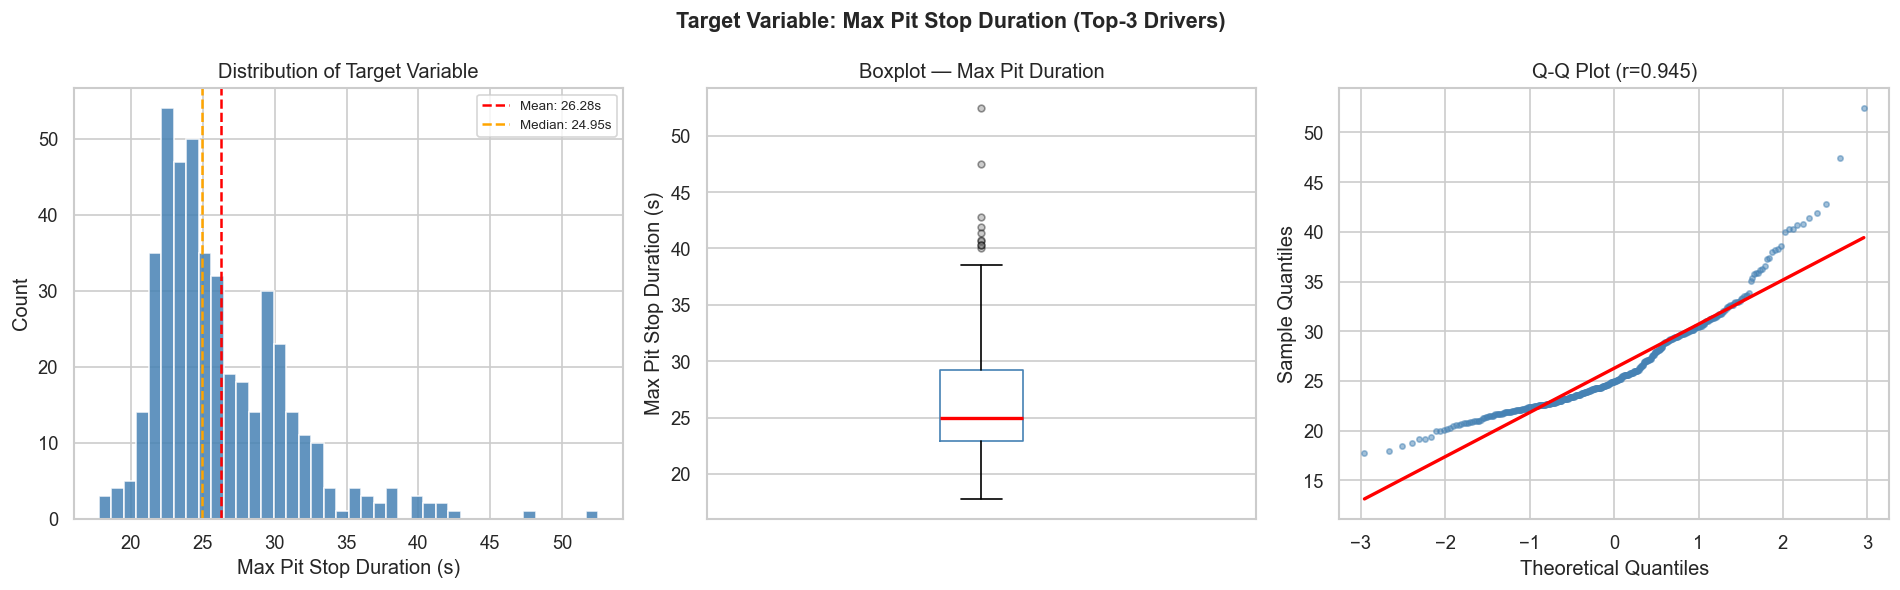

Skewness: 1.475
Kurtosis: 3.506
Shapiro-Wilk test: stat=0.8896, p=0.0000 → NOT normal


In [127]:
print('\n=== Target Variable Visualization ===')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
axes[0].hist(pit_merged_df_clean['top3_pit_stops_max_duration_s'].dropna(), bins=40,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(pit_merged_df_clean['top3_pit_stops_max_duration_s'].mean(), color='red',
                linestyle='--', label=f'Mean: {pit_merged_df_clean["top3_pit_stops_max_duration_s"].mean():.2f}s')
axes[0].axvline(pit_merged_df_clean['top3_pit_stops_max_duration_s'].median(), color='orange',
                linestyle='--', label=f'Median: {pit_merged_df_clean["top3_pit_stops_max_duration_s"].median():.2f}s')
axes[0].set_xlabel('Max Pit Stop Duration (s)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Target Variable')
axes[0].legend(fontsize=8)

# Boxplot
axes[1].boxplot(pit_merged_df_clean['top3_pit_stops_max_duration_s'].dropna(),
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.4))
axes[1].set_ylabel('Max Pit Stop Duration (s)')
axes[1].set_title('Boxplot — Max Pit Duration')
axes[1].set_xticks([])

# Q-Q plot
clean_vals = pit_merged_df_clean['top3_pit_stops_max_duration_s'].dropna()
(osm, osr), (slope, intercept, r) = stats.probplot(clean_vals, dist='norm')
axes[2].scatter(osm, osr, s=10, alpha=0.5, color='steelblue')
axes[2].plot(osm, slope*np.array(osm)+intercept, color='red', linewidth=2)
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')
axes[2].set_title(f'Q-Q Plot (r={r:.3f})')

plt.suptitle('Target Variable: Max Pit Stop Duration (Top-3 Drivers)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness: {clean_vals.skew():.3f}')
print(f'Kurtosis: {clean_vals.kurt():.3f}')
stat, p = stats.shapiro(clean_vals.sample(min(len(clean_vals), 200), random_state=42))
print(f'Shapiro-Wilk test: stat={stat:.4f}, p={p:.4f} → {"NOT normal" if p < 0.05 else "Normal"}')

**DISTRIBUTION OF ALL PIT STOP DURATIONS (TOP-3 DRIVERS)**

Let's look at the distribution of individual pit stop durations and how they vary depending on whether it's the 1st, 2nd, 3rd, or 4th stop of the race.

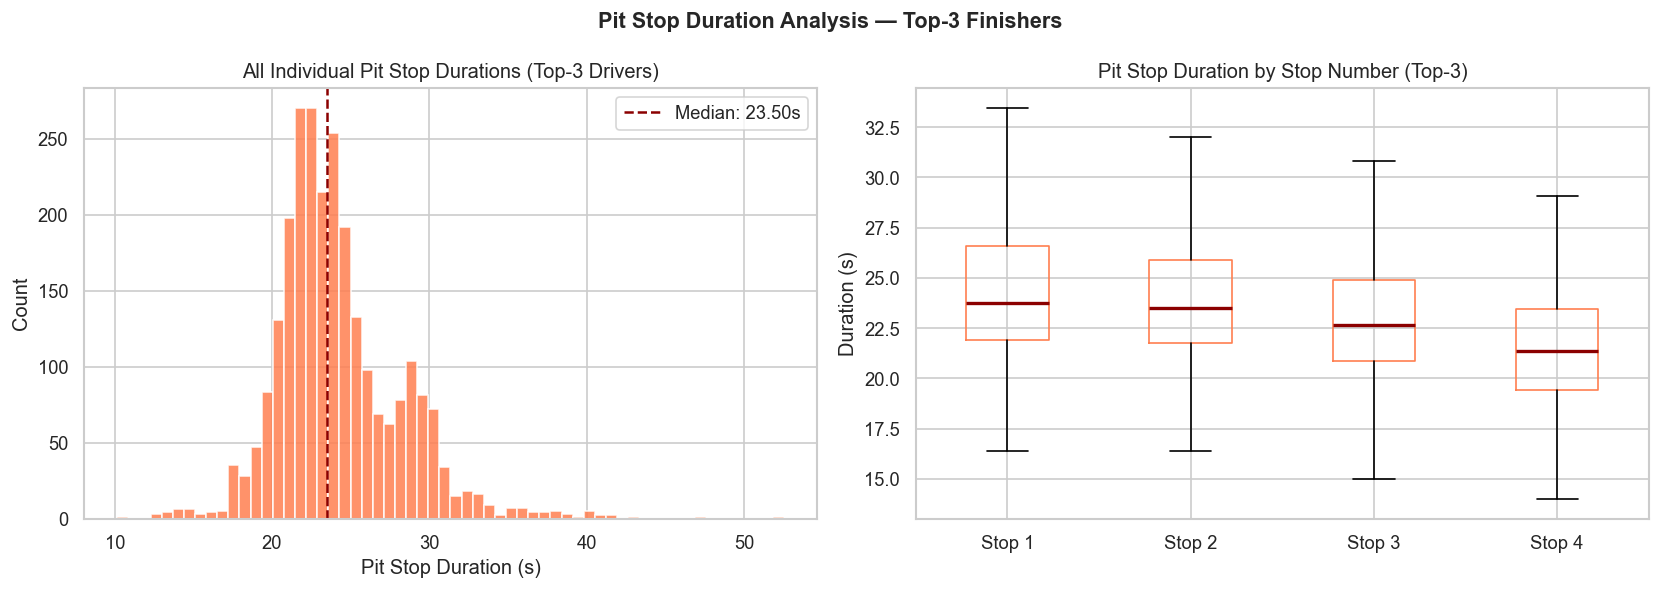

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all individual stops
axes[0].hist(top3_pits['duration'].dropna(), bins=60,
             color='coral', edgecolor='white', alpha=0.85)
axes[0].axvline(top3_pits['duration'].median(), color='darkred',
                linestyle='--', label=f'Median: {top3_pits["duration"].median():.2f}s')
axes[0].set_xlabel('Pit Stop Duration (s)')
axes[0].set_ylabel('Count')
axes[0].set_title('All Individual Pit Stop Durations (Top-3 Drivers)')
axes[0].legend()

# By stop number
stop_data = [top3_pits[top3_pits['stop'] == s]['duration'].dropna().values
             for s in range(1, 5)]
axes[1].boxplot(stop_data, tick_labels=['Stop 1', 'Stop 2', 'Stop 3', 'Stop 4'],
                boxprops=dict(color='coral'),
                medianprops=dict(color='darkred', linewidth=2),
                showfliers=False)
axes[1].set_ylabel('Duration (s)')
axes[1].set_title('Pit Stop Duration by Stop Number (Top-3)')

plt.suptitle('Pit Stop Duration Analysis — Top-3 Finishers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**MAX PIT DURATION OVER THE SEASONS**

How has the maximum pit stop duration evolved over the years?

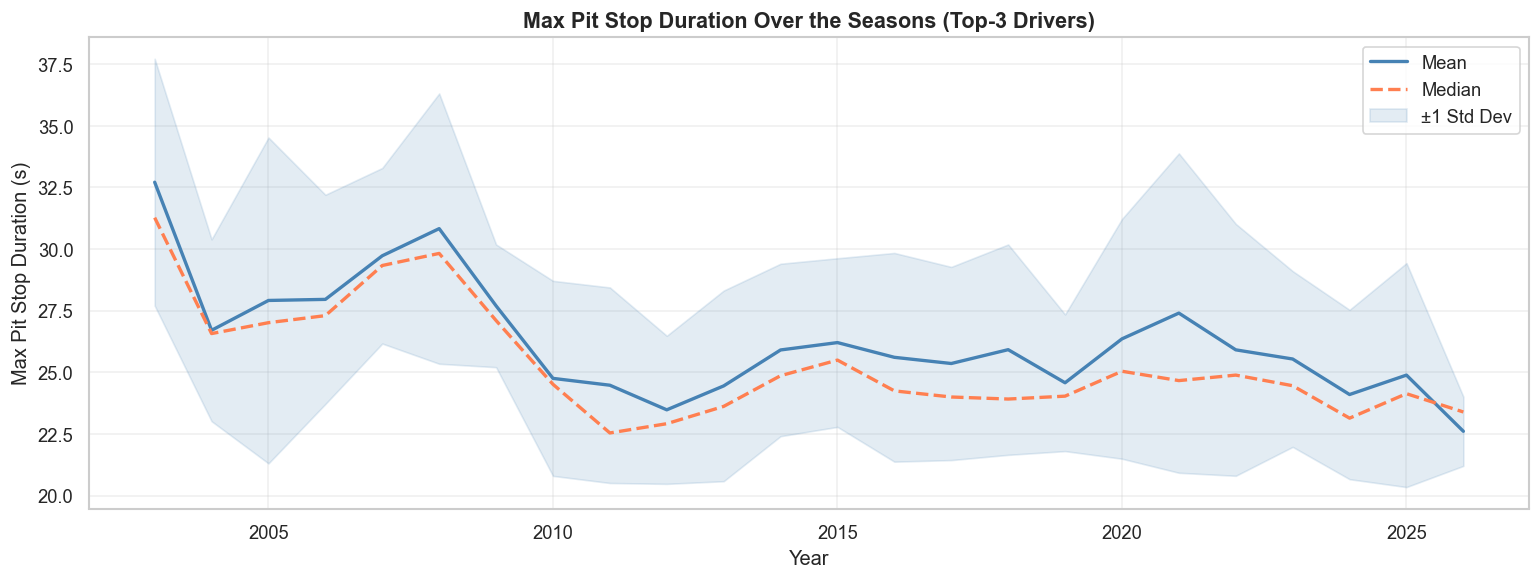

In [129]:
annual = pit_merged_df_clean.groupby('race_year')['top3_pit_stops_max_duration_s'].agg(['mean', 'median', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(annual['race_year'], annual['mean'],   label='Mean',   color='steelblue', linewidth=2)
ax.plot(annual['race_year'], annual['median'], label='Median', color='coral',     linewidth=2, linestyle='--')
ax.fill_between(annual['race_year'],
                annual['mean'] - annual['std'],
                annual['mean'] + annual['std'],
                alpha=0.15, color='steelblue', label='±1 Std Dev')
ax.set_xlabel('Year')
ax.set_ylabel('Max Pit Stop Duration (s)')
ax.set_title('Max Pit Stop Duration Over the Seasons (Top-3 Drivers)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**MAX PIT DURATION BY CIRCUIT**

Different tracks have different pit lane lengths and speed limits.

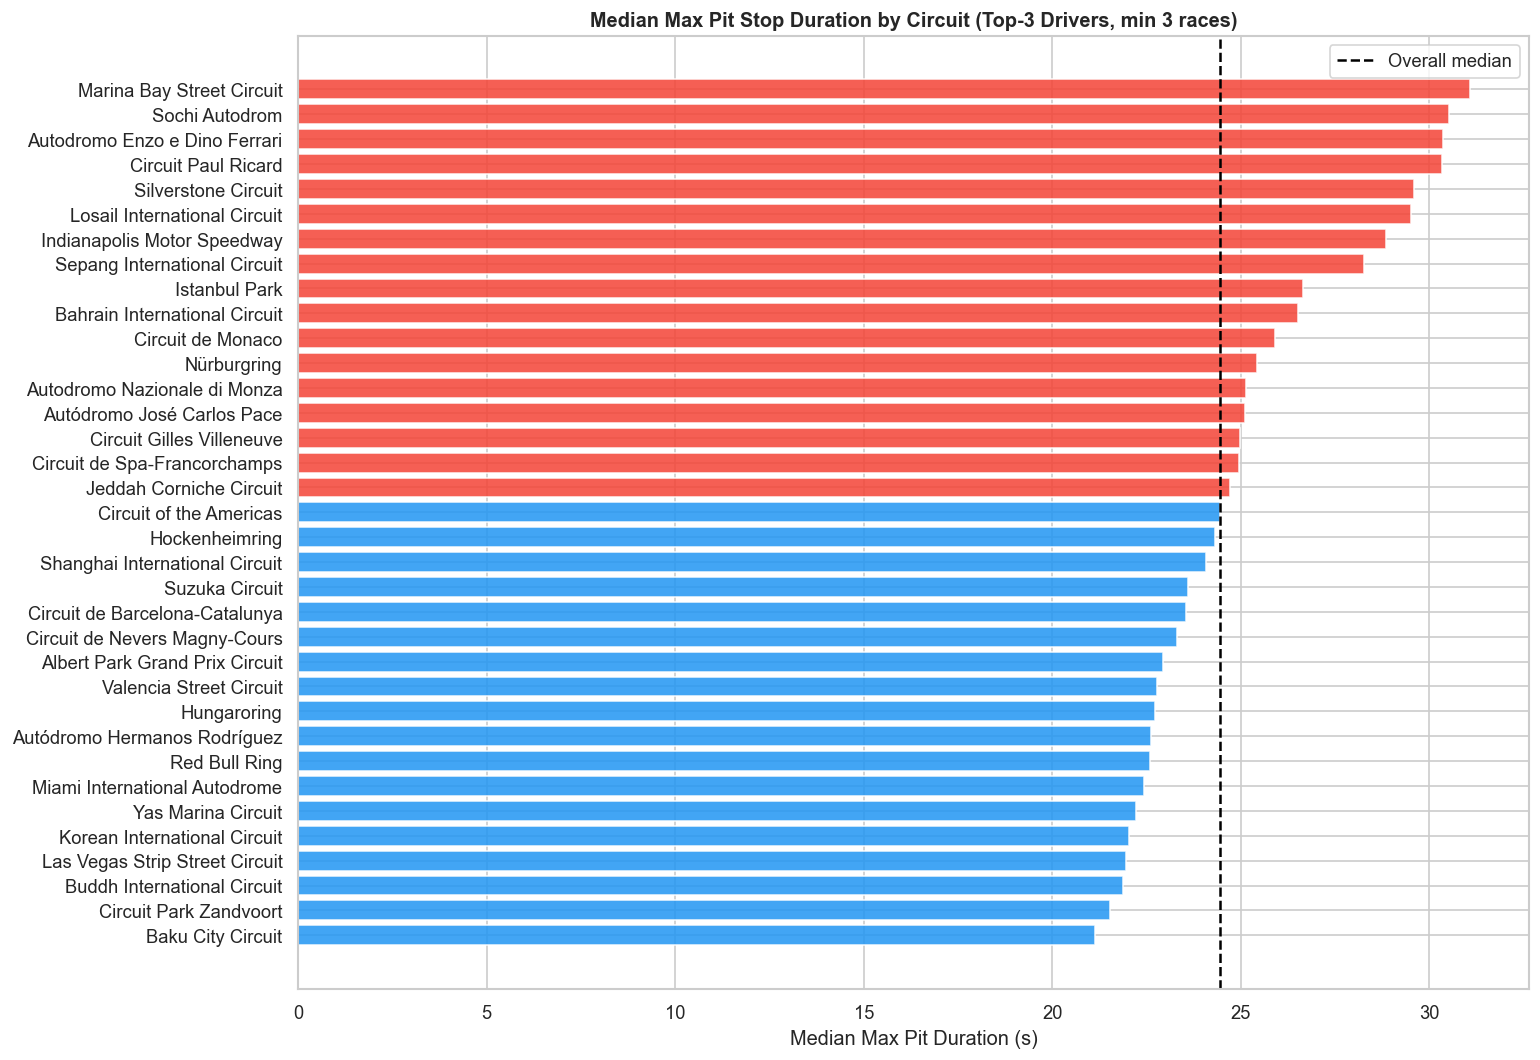

In [130]:
circuit_pit = (
    pit_merged_df_clean.groupby('race_circuit')['top3_pit_stops_max_duration_s']
    .agg(['mean', 'median', 'count'])
    .query('count >= 3')
    .sort_values('median')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 9))
colors = ['#2196F3' if v <= circuit_pit['median'].median() else '#F44336'
          for v in circuit_pit['median']]
ax.barh(circuit_pit['race_circuit'], circuit_pit['median'], color=colors, alpha=0.85)
ax.axvline(circuit_pit['median'].median(), color='black', linestyle='--',
           linewidth=1.5, label='Overall median')
ax.set_xlabel('Median Max Pit Duration (s)')
ax.set_title('Median Max Pit Stop Duration by Circuit (Top-3 Drivers, min 3 races)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


**MAX PIT DURATION BY CONSTRUCTOR (TEAM)**

Let's see which teams have the most efficient pit crews.

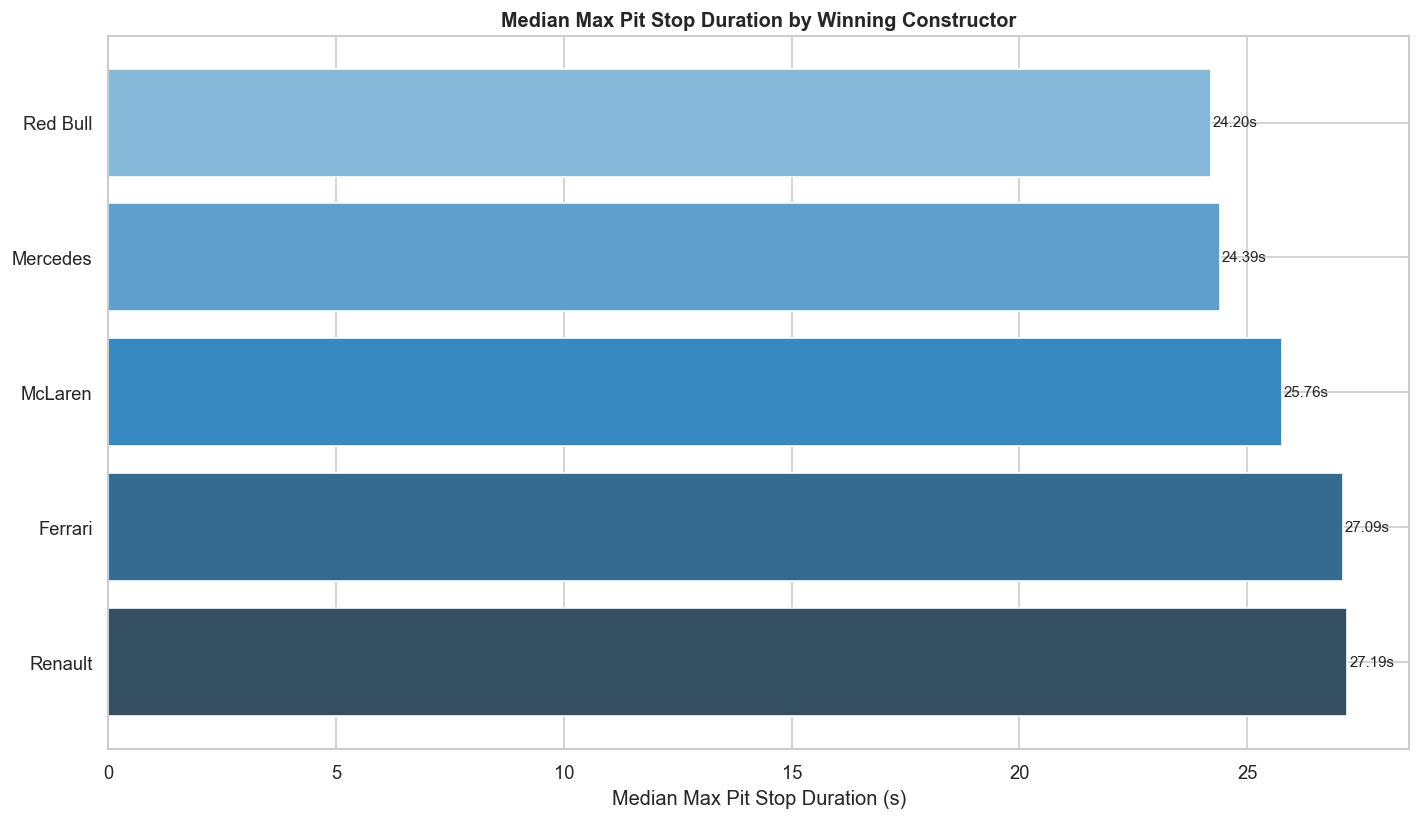

In [131]:
# Merge constructor info into pit_merged_df_clean (using the 1st place constructor name as proxy)
modeling_with_team = pit_merged_df_clean.rename(columns={'pos1_team': 'team'}).copy()

team_stats = (
    modeling_with_team.groupby('team')['top3_pit_stops_max_duration_s']
    .agg(['mean', 'median', 'count'])
    .query('count >= 10')
    .sort_values('median')
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(team_stats['team'], team_stats['median'],
               color=sns.color_palette('Blues_d', len(team_stats)))
for bar, val in zip(bars, team_stats['median']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}s', va='center', fontsize=9)
ax.set_xlabel('Median Max Pit Stop Duration (s)')
ax.set_title('Median Max Pit Stop Duration by Winning Constructor',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**SCATTERPLOTS - PREDICTORS VS TARGET**

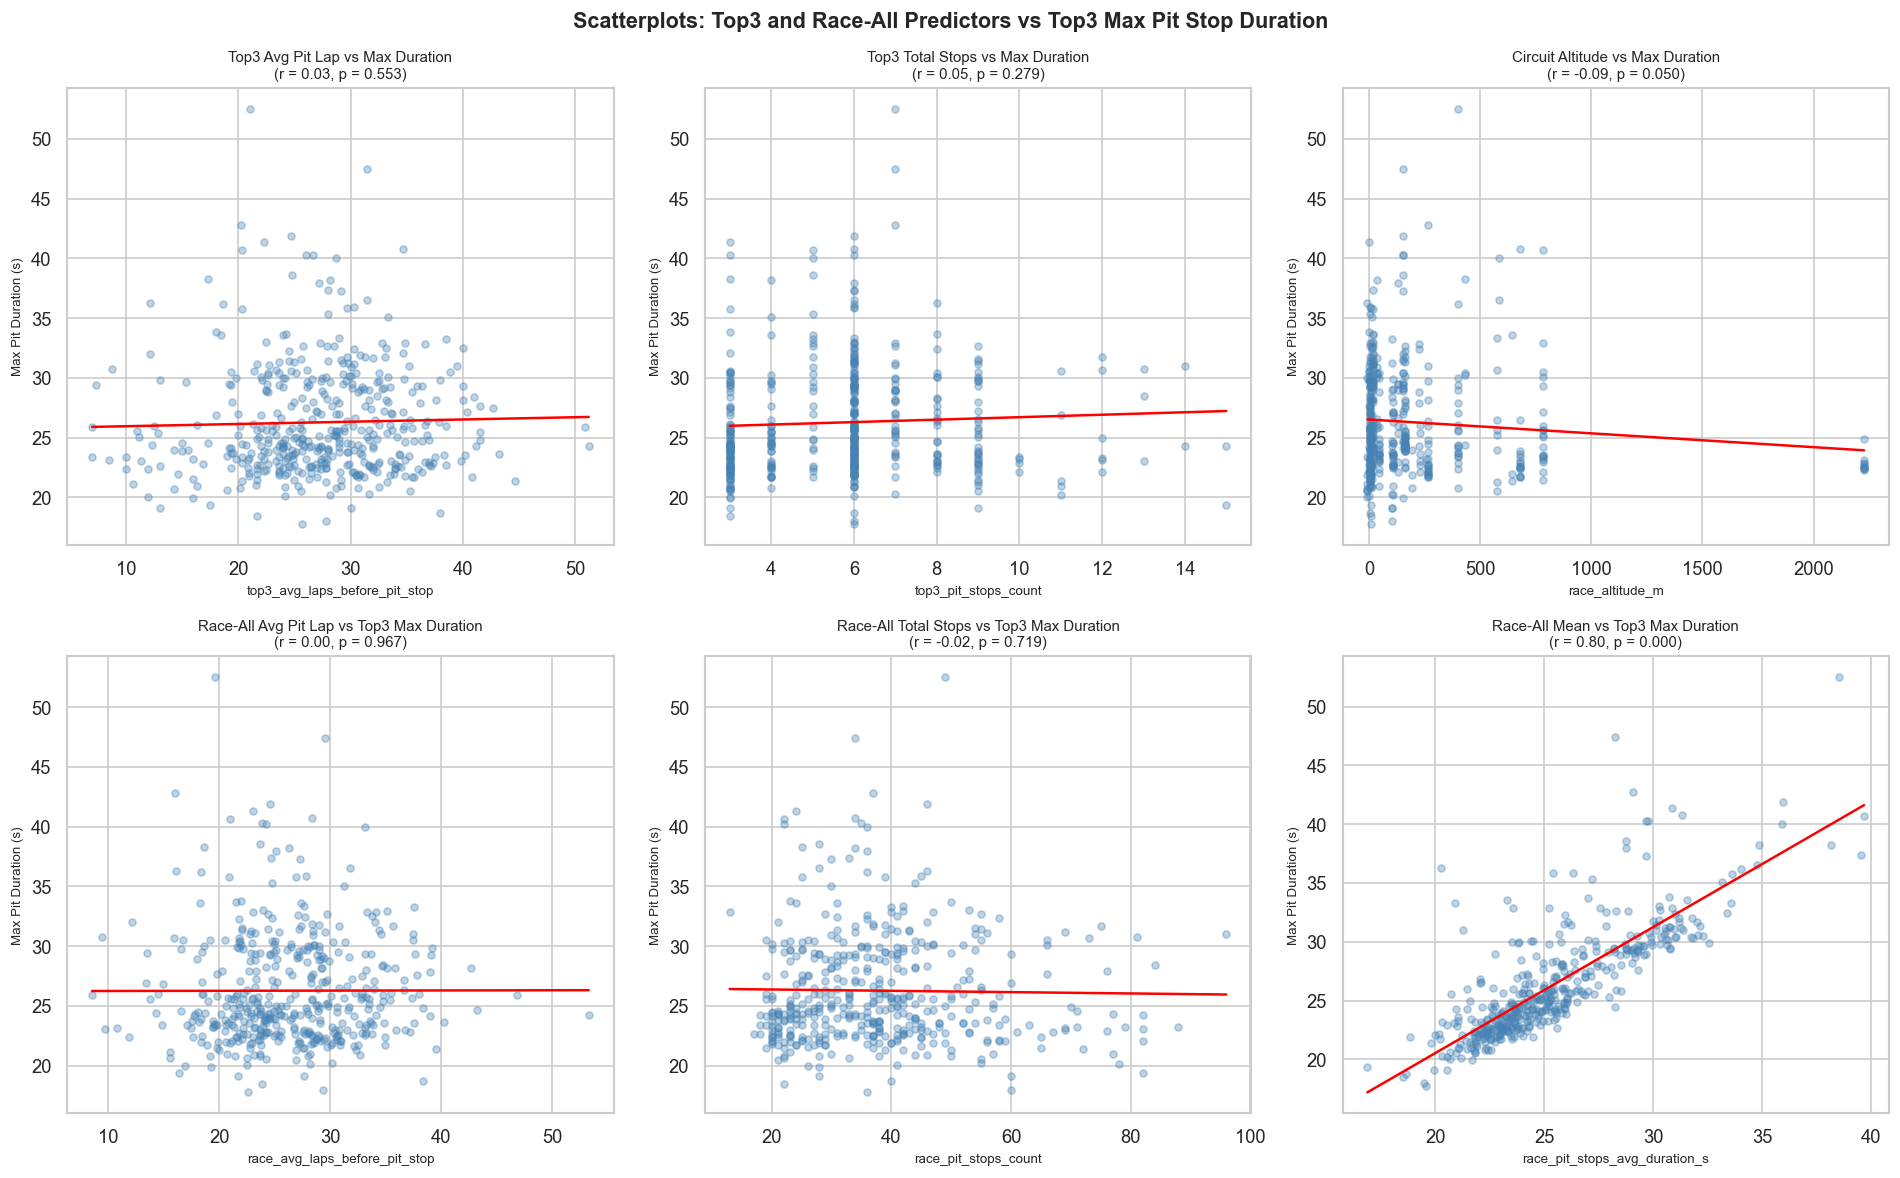

In [132]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

pairs = [
    ('top3_avg_laps_before_pit_stop',     'top3_pit_stops_max_duration_s', 'Top3 Avg Pit Lap vs Max Duration'),
    ('top3_pit_stops_count',       'top3_pit_stops_max_duration_s', 'Top3 Total Stops vs Max Duration'),
    ('race_altitude_m', 'top3_pit_stops_max_duration_s', 'Circuit Altitude vs Max Duration'),
    ('race_avg_laps_before_pit_stop', 'top3_pit_stops_max_duration_s', 'Race-All Avg Pit Lap vs Top3 Max Duration'),
    ('race_pit_stops_count',   'top3_pit_stops_max_duration_s', 'Race-All Total Stops vs Top3 Max Duration'),
    ('race_pit_stops_avg_duration_s', 'top3_pit_stops_max_duration_s', 'Race-All Mean vs Top3 Max Duration'),
]

for ax, (x, y, title) in zip(axes, pairs):
    tmp = pit_merged_df_clean[[x, y]].dropna()
    ax.scatter(tmp[x], tmp[y], alpha=0.35, s=18, color='steelblue')
    if len(tmp) > 3:
        m, b = np.polyfit(tmp[x], tmp[y], 1)
        xline = np.linspace(tmp[x].min(), tmp[x].max(), 100)
        ax.plot(xline, m*xline+b, color='red', linewidth=1.5)
        r, p = stats.pearsonr(tmp[x], tmp[y])
        ax.set_title(f'{title}\n(r = {r:.2f}, p = {p:.3f})', fontsize=9)
    else:
        ax.set_title(title, fontsize=9)
    ax.set_xlabel(x, fontsize=8)
    ax.set_ylabel('Max Pit Duration (s)', fontsize=8)

plt.suptitle('Scatterplots: Top3 and Race-All Predictors vs Top3 Max Pit Stop Duration',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**CORRELATION MATRIX**

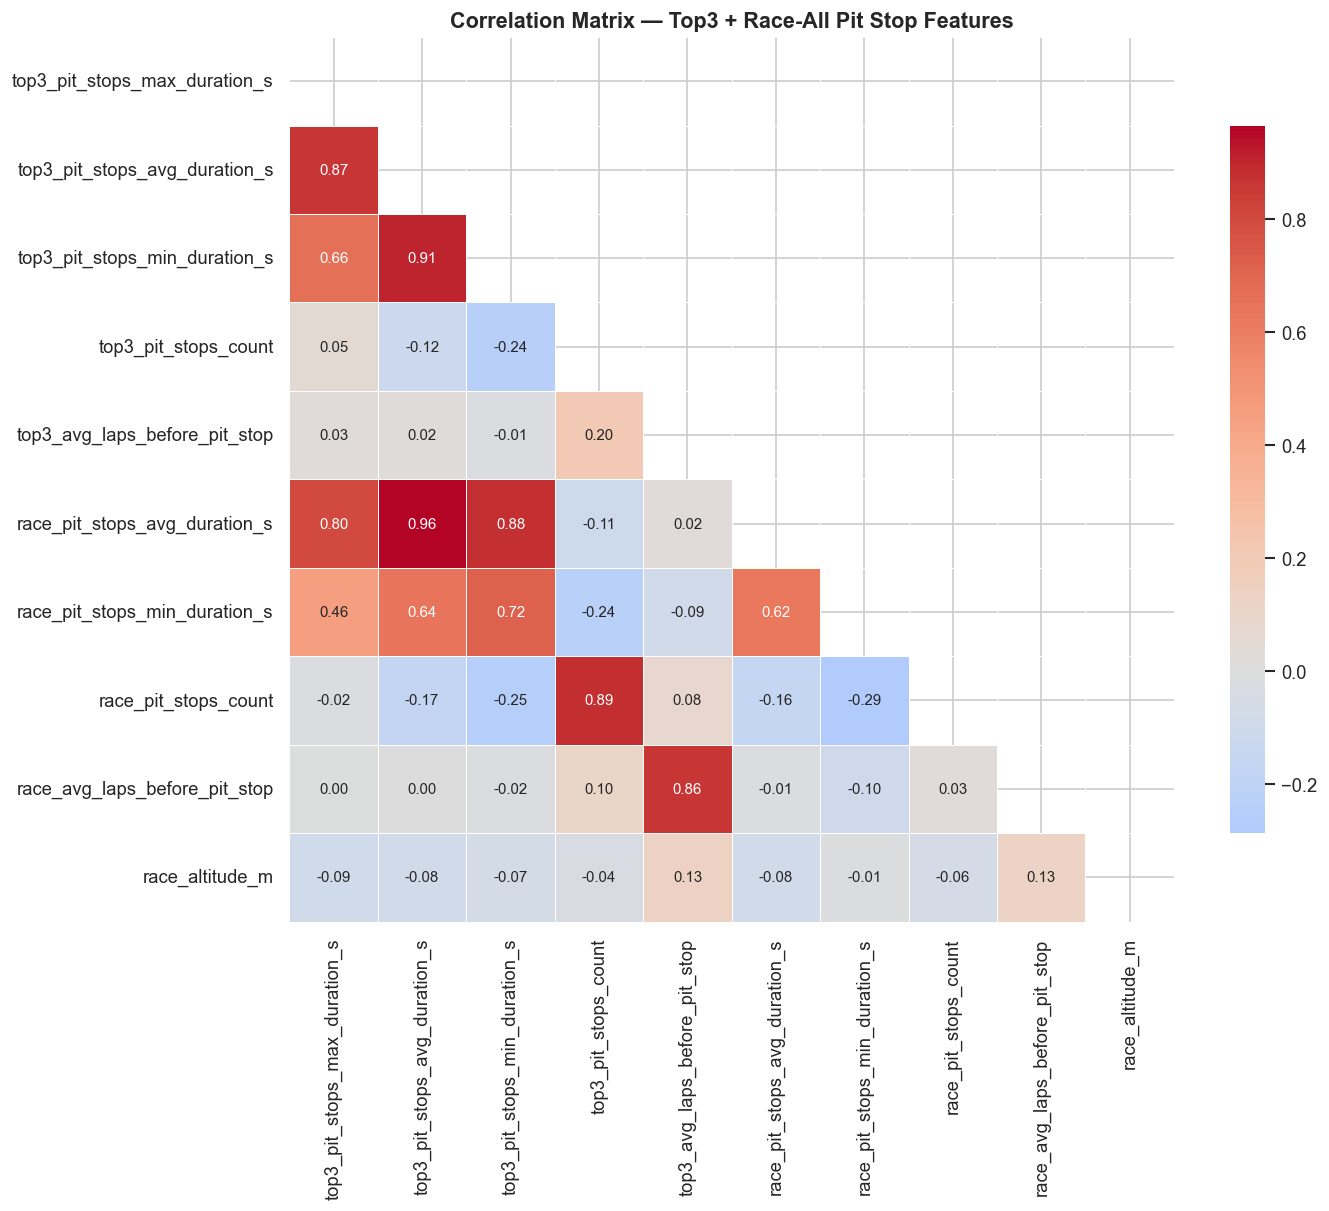

In [133]:
corr_cols = [
    'top3_pit_stops_max_duration_s', 'top3_pit_stops_avg_duration_s', 'top3_pit_stops_min_duration_s',
    'top3_pit_stops_count', 'top3_avg_laps_before_pit_stop', 'race_pit_stops_avg_duration_s', 'race_pit_stops_min_duration_s',
    'race_pit_stops_count', 'race_avg_laps_before_pit_stop', 'race_altitude_m'
]

corr_data = pit_merged_df_clean[corr_cols].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, square=True, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 9}
)
ax.set_title('Correlation Matrix — Top3 + Race-All Pit Stop Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**PIT STOP TIMING - WHEN IN THE RACE DO TOP-3 DRIVERS STOP?**

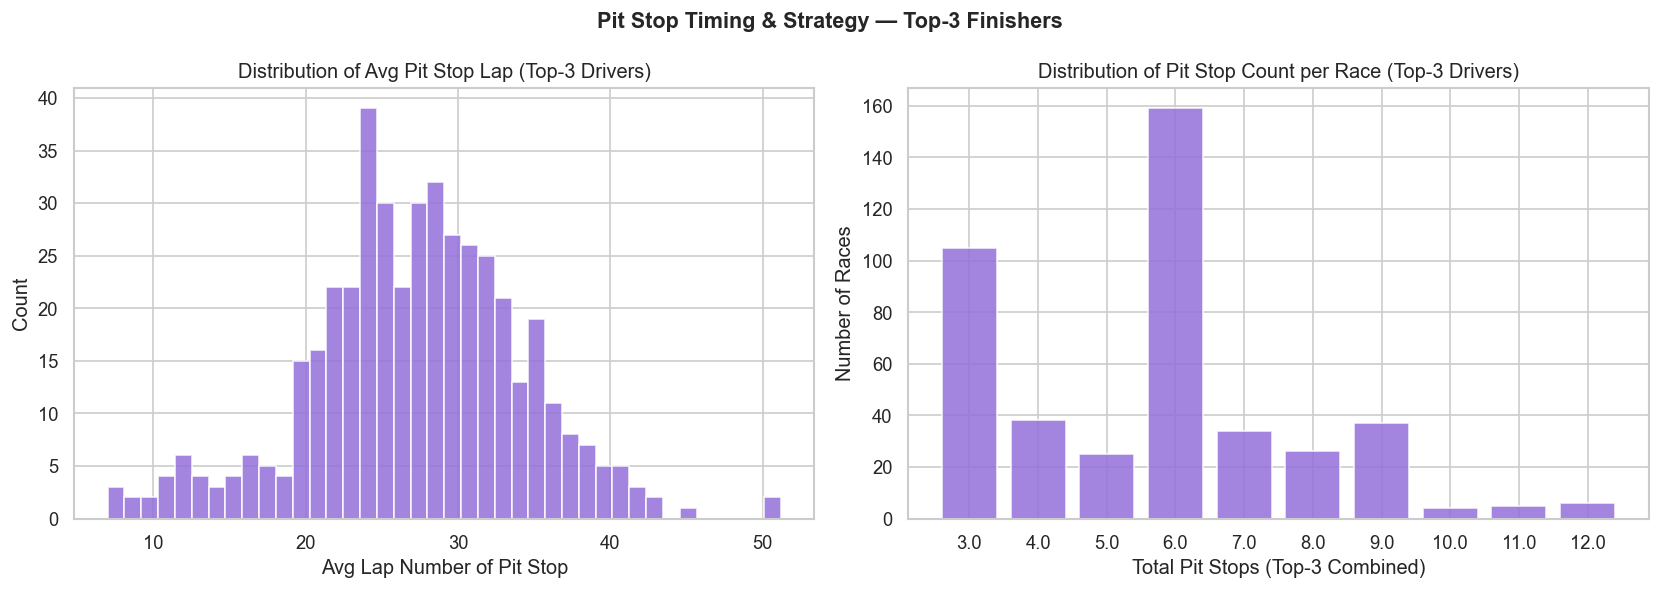

In [134]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pit_merged_df_clean['top3_avg_laps_before_pit_stop'].dropna(), bins=40,
             color='mediumpurple', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Avg Lap Number of Pit Stop')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Avg Pit Stop Lap (Top-3 Drivers)')

stop_counts = pit_merged_df_clean['top3_pit_stops_count'].value_counts().sort_index().head(10)
axes[1].bar(stop_counts.index.astype(str), stop_counts.values,
            color='mediumpurple', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Total Pit Stops (Top-3 Combined)')
axes[1].set_ylabel('Number of Races')
axes[1].set_title('Distribution of Pit Stop Count per Race (Top-3 Drivers)')

plt.suptitle('Pit Stop Timing & Strategy — Top-3 Finishers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Identification of Predictor & Response Variables**

## EDA SUMMARY AND KEY FINDINGS
**RESPONSE (TARGET) VARIABLE**

| Variable | Type | Description / EDA Finding |
| :---- | :---- | :---- |
| **top3_pit_stops_max_duration_s** | Continuous (seconds) | Maximum pit stop duration among the top-3 finishers in a given race — the primary prediction target. *EDA notes it is right-skewed; a log-transformation is recommended.* |

**POTENTIAL PREDICTOR VARIABLES**

**Race-Level Predictors**

| Variable | Type | Rationale / EDA Finding |
| :---- | :---- | :---- |
| race_year | Ordinal | Captures observed downward trend in average pit stop times (technical improvements from 2011 onward). |
| race_circuit | Categorical | Significant variation in median durations across circuits due to pit lane and track characteristics. |
| race_country | Categorical | Proxy for circuit type, logistics, and local racing conditions. |
| race_altitude_m | Continuous | Higher altitude may affect car cooling and tire wear, impacting stop strategy. |

**Performance Predictors (Top-3 and Race-All)**

| Variable | Type | Rationale / EDA Finding |
| :---- | :---- | :---- |
| top3_pit_stops_count | Discrete | Total top-3 pit stops in the race. |
| race_pit_stops_count | Discrete | Total race-wide pit stops (all drivers) as strategic context baseline. |
| top3_avg_laps_before_pit_stop | Continuous | Mean top-3 pit timing lap. |
| race_avg_laps_before_pit_stop | Continuous | Mean race-wide pit timing lap baseline. |
| pos1_team / pos2_team / pos3_team | Categorical | Team-level operational performance context. |
| top3_avg_* features | Continuous | Explicit average of winner/runner-up/third-place values for each numeric metric family. |

Our exploratory analysis from the current notebook dataset identifies the following data-backed findings:

**1. Target Distribution & Sample Scope**

* **Current sample size:** `pit_merged_df_clean` contains **451 races** spanning **2003-2026** across **38 circuits** and **30 countries**.
* **Right-skewed target persists:** `top3_pit_stops_max_duration_s` is right-skewed (**skew = 1.47**, **kurtosis = 3.50**).
* **Normality check:** Shapiro-Wilk on a 200-race sample gives **p = 1.46e-05**, so we reject normality for the target distribution.

**2. Time Trend**

* **Downward yearly trend:** The annual mean of `top3_pit_stops_max_duration_s` declines over time with slope about **-0.21 sec/year** (correlation with `race_year` **r = -0.64**), indicating gradual pit-stop performance improvements.

**3. Predictive Signal Strength (Current Feature Set)**

* **Strongest linear relationships with target (leakage risk — see section 6):**
  * `top3_pit_stops_avg_duration_s` vs `top3_pit_stops_max_duration_s`: **r = 0.87** (very strong)
  * `top3_pit_stops_min_duration_s` vs `top3_pit_stops_max_duration_s`: **r = 0.66** (strong)
* **Weak/non-significant relationships in current data:**
  * `top3_pit_stops_count`: **r = 0.05, p = 0.249**
  * `top3_avg_laps_before_pit_stop`: **r = 0.03, p = 0.489**
  * `race_pit_stops_count`: approximately near-zero linear signal
  * `race_avg_laps_before_pit_stop`: approximately near-zero linear signal
  * `race_altitude_m`: **r = -0.09, p = 0.052** (not significant at p < 0.05)

**4. Circuit-Level Variation**

* Using circuits with at least 3 races (**35 circuits**), median max pit duration differs noticeably by venue.
* **Lower-median group (fastest among current sample):** Baku City Circuit, Circuit Park Zandvoort, Buddh International Circuit, Las Vegas Strip Street Circuit, Korean International Circuit.
* **Higher-median group (slowest among current sample):** Silverstone Circuit, Circuit Paul Ricard, Autodromo Enzo e Dino Ferrari, Sochi Autodrom, Marina Bay Street Circuit.

**5. Data Quality Status in Final Working Set**

* After cleaning, missingness is fully resolved for key modeling fields in `pit_merged_df_clean`:
  * `top3_pit_stops_max_duration_s`: 0 missing
  * `quali_lap_time_s`: 0 missing
  * `pos1_qualifying_position` / `pos2_qualifying_position` / `pos3_qualifying_position`: 0 missing
  * `race_start_position`: 0 missing

**6. Modeling Guardrail**

* To avoid target leakage, keep `top3_pit_stops_avg_duration_s` and `top3_pit_stops_min_duration_s` out of the final predictive feature set, since both are highly correlated derivatives of pit-stop duration behavior in the same race context.